<a href="https://colab.research.google.com/github/TrEk-02/Exploratory-Data-Analysis-Modelling/blob/main/CS105_Project_Submission_(Final)_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
Singapore Management University<br>
CS105 Statistical Thinking for Data Science, 2025/26 Term 2
</div>

# CS105 Group Project Submission (Part I)

-----
Provide your team details, including section, team number, team members, and the name of the dataset.
Complete all of the following sections. For any part requiring code to derive your answers, please create a code cell immediately below your response and run the code.
To edit any markdown cell, double click the cell; after editing, execute the markdown cell to collapse it.
<br>
-----

## Declaration

<span style="color:red">By submitting this notebook, we declare that **no part of this submission is generated by any AI tool**. We understand that AI-generated submissions will be considered as plagiarism, and just like other plagirisum cases, disciplinary actions will be imposed.</span>

#### Section: G4
#### Team: 2
#### Members:
1. Gari Boey Lai
2. Lee Xuan Ying, Felicia
3. Tan Sze Lui, Rae
4. Tung Geng Hong

#### Dataset:
housing.csv

## Part I: Exploratory Data Analysis (EDA) [8% of final grade]

In [ ]:
import os
import pandas as pd

# load locally for final submission, only works on local jupyter notebook i think?? not so sure
if os.path.exists('housing.csv'):
    df = pd.read_csv('housing.csv')
    print("Loaded from local directory.")

# shared drive for team collab, can remove later
else:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        # ensure we all have the same file directory, else this will not run
        df = pd.read_csv('/content/drive/MyDrive/CS105_Project/housing.csv')
        print("Loaded from Google Drive.")
    except:
        print("Error: Could not find housing.csv. Please check file path.")

Mounted at /content/drive
Loaded from Google Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### 1. Overview of dataset [15% of Part I]

**a.** Summarise the background of the dataset [limited to 50 words]

**Response.**

The dataset contains 506 neighbourhoods described by 13 variables encompassing property characteristics, neighbourhood demographics, environmental factors, and accessibility measures. It can be used to analyse factors influencing housing prices across neighbourhoods.

**b.** State the size of the dataset

**Response.**

The dataset has 506 rows and 14 columns

In [ ]:
df.shape

(506, 14)

**c.** For each variable, describe what it represents and its data type (numerical or categorical)

| Variable                  | Type        | Description                                                                                                     |
| ------------------------- | ----------- | --------------------------------------------------------------------------------------------------------------- |
| **ID**                    | Categorical  | Unique identifier for the housing properties in the area                                                        |
| **Non_Retail**            | Numerical   | Percentage of business area dedicated to non-retail purposes                                          |
| **Pollutants**            | Numerical   | Concentration of pollutants (parts per 10 million)                                                          |
| **Rooms**                 | Numerical   | Number of rooms per unit                                                                               |
| **Old_Housing**           | Numerical   | Percentage of units built before second world war                                                         |
| **Distance_Office**       | Numerical   | Weighted distances to major office areas                                                             |
| **Tax_Rate**              | Numerical   | Property tax class charged per $10,000 for properties in the area                            |
| **Student_Teacher_Ratio** | Numerical   | Ratio of students to one teacher in schools (indicator of education quality)                                    |
| **Low_Income**            | Numerical   | Percentage of lower-income households                                                                |
| **Price**                 | Numerical   | Median price of the properties in the area, per thousands of dollars                                           |
| **Crime_Rate**            | Categorical | Classification of crime level, measured by crime rate per capita, in the area in 3 categories (Low, Moderate, High)                            |
| **Residential_Area**      | Categorical | Classification of land available for residential use in 5 categories (Very Low, Low, Moderate, High, Very High) based on percentage of residential area greater than 25000 square feet |
| **River**                 | Categorical | Classification of the proximity of a bridge (river) from the area in 2 categories (Near, Far)                          |
| **Highway_Access**        | Categorical | Classification of accessibility to highways in 3 categories (Low, Moderate, High)                               |


# 2. Data pre-processing [35% of Part I]

**a.** For each variable, determine the percentage of missing data. For any column with missing data, describe how you resolve the issue. Clearly state any assumption you made.


**Response.**

Only Crime_Rate (~ 4.55%) and Low_Income (~ 4.35%) have missing values. The rest of the variables have 0% missing data.

For Crime_Rate, replacing the missing data with the most frequent value (i.e. Low; the mode) is likely most appropriate because it is a categorical variable with no mean or median.

For Low_Income, replacing the missing data requires the median value because this method is unaffected by outliers and its distribution is right-skewed.

In [ ]:
print((df.isnull().sum() / len(df) * 100).round(2)) #to find the missing values percentages

ID                       0.00
Crime_Rate               4.55
Residential_Area         0.00
Non_Retail               0.00
River                    0.00
Pollutants               0.00
Rooms                    0.00
Old_Housing              0.00
Distance_Office          0.00
Highway_Access           0.00
Tax_Rate                 0.00
Student_Teacher_Ratio    0.00
Low_Income               4.35
Price                    0.00
dtype: float64


In [ ]:
#fill in missing values
df['Crime_Rate'] = df['Crime_Rate'].fillna(df['Crime_Rate'].mode()[0])
df['Low_Income'] = df['Low_Income'].fillna(df['Low_Income'].median())

#verify no missing values remain
print(df.isnull().sum())

ID                       0
Crime_Rate               0
Residential_Area         0
Non_Retail               0
River                    0
Pollutants               0
Rooms                    0
Old_Housing              0
Distance_Office          0
Highway_Access           0
Tax_Rate                 0
Student_Teacher_Ratio    0
Low_Income               0
Price                    0
dtype: int64


**b.** For each variable, identify outliers (if any) and describe how you resolve the issue. Clearly state any assumption you made.

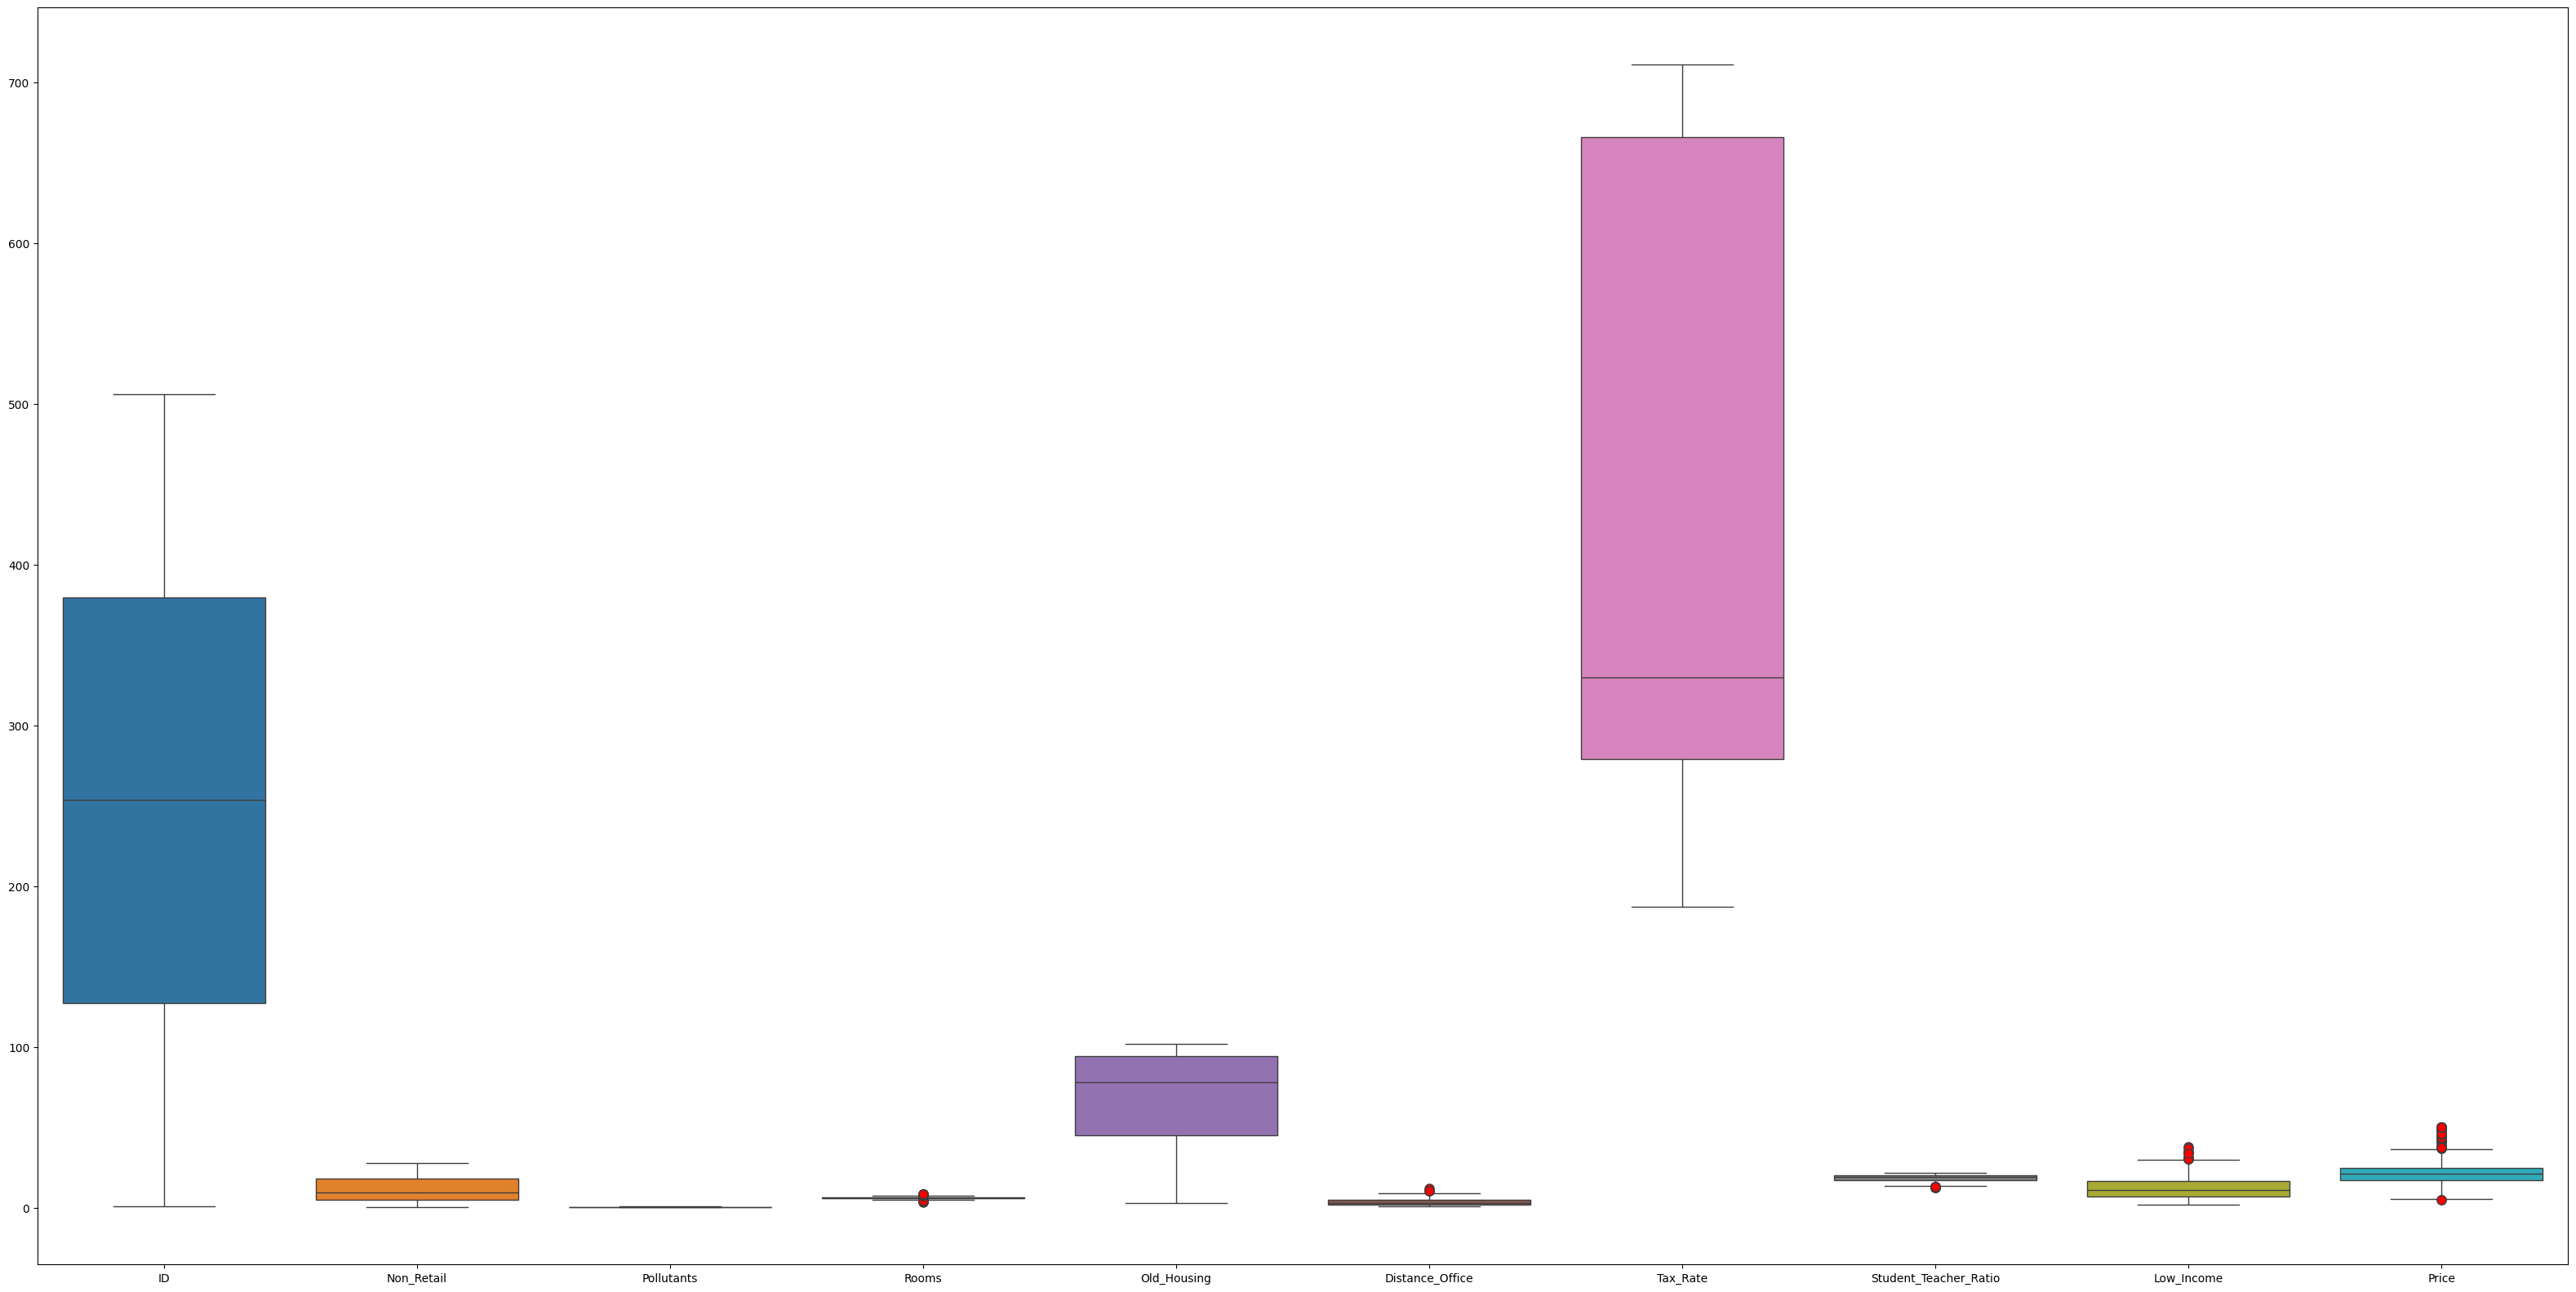

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#overview of all variables
fig= plt.subplots(figsize=(40, 20))
sns.boxplot(df,
           flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 8})
plt.show()

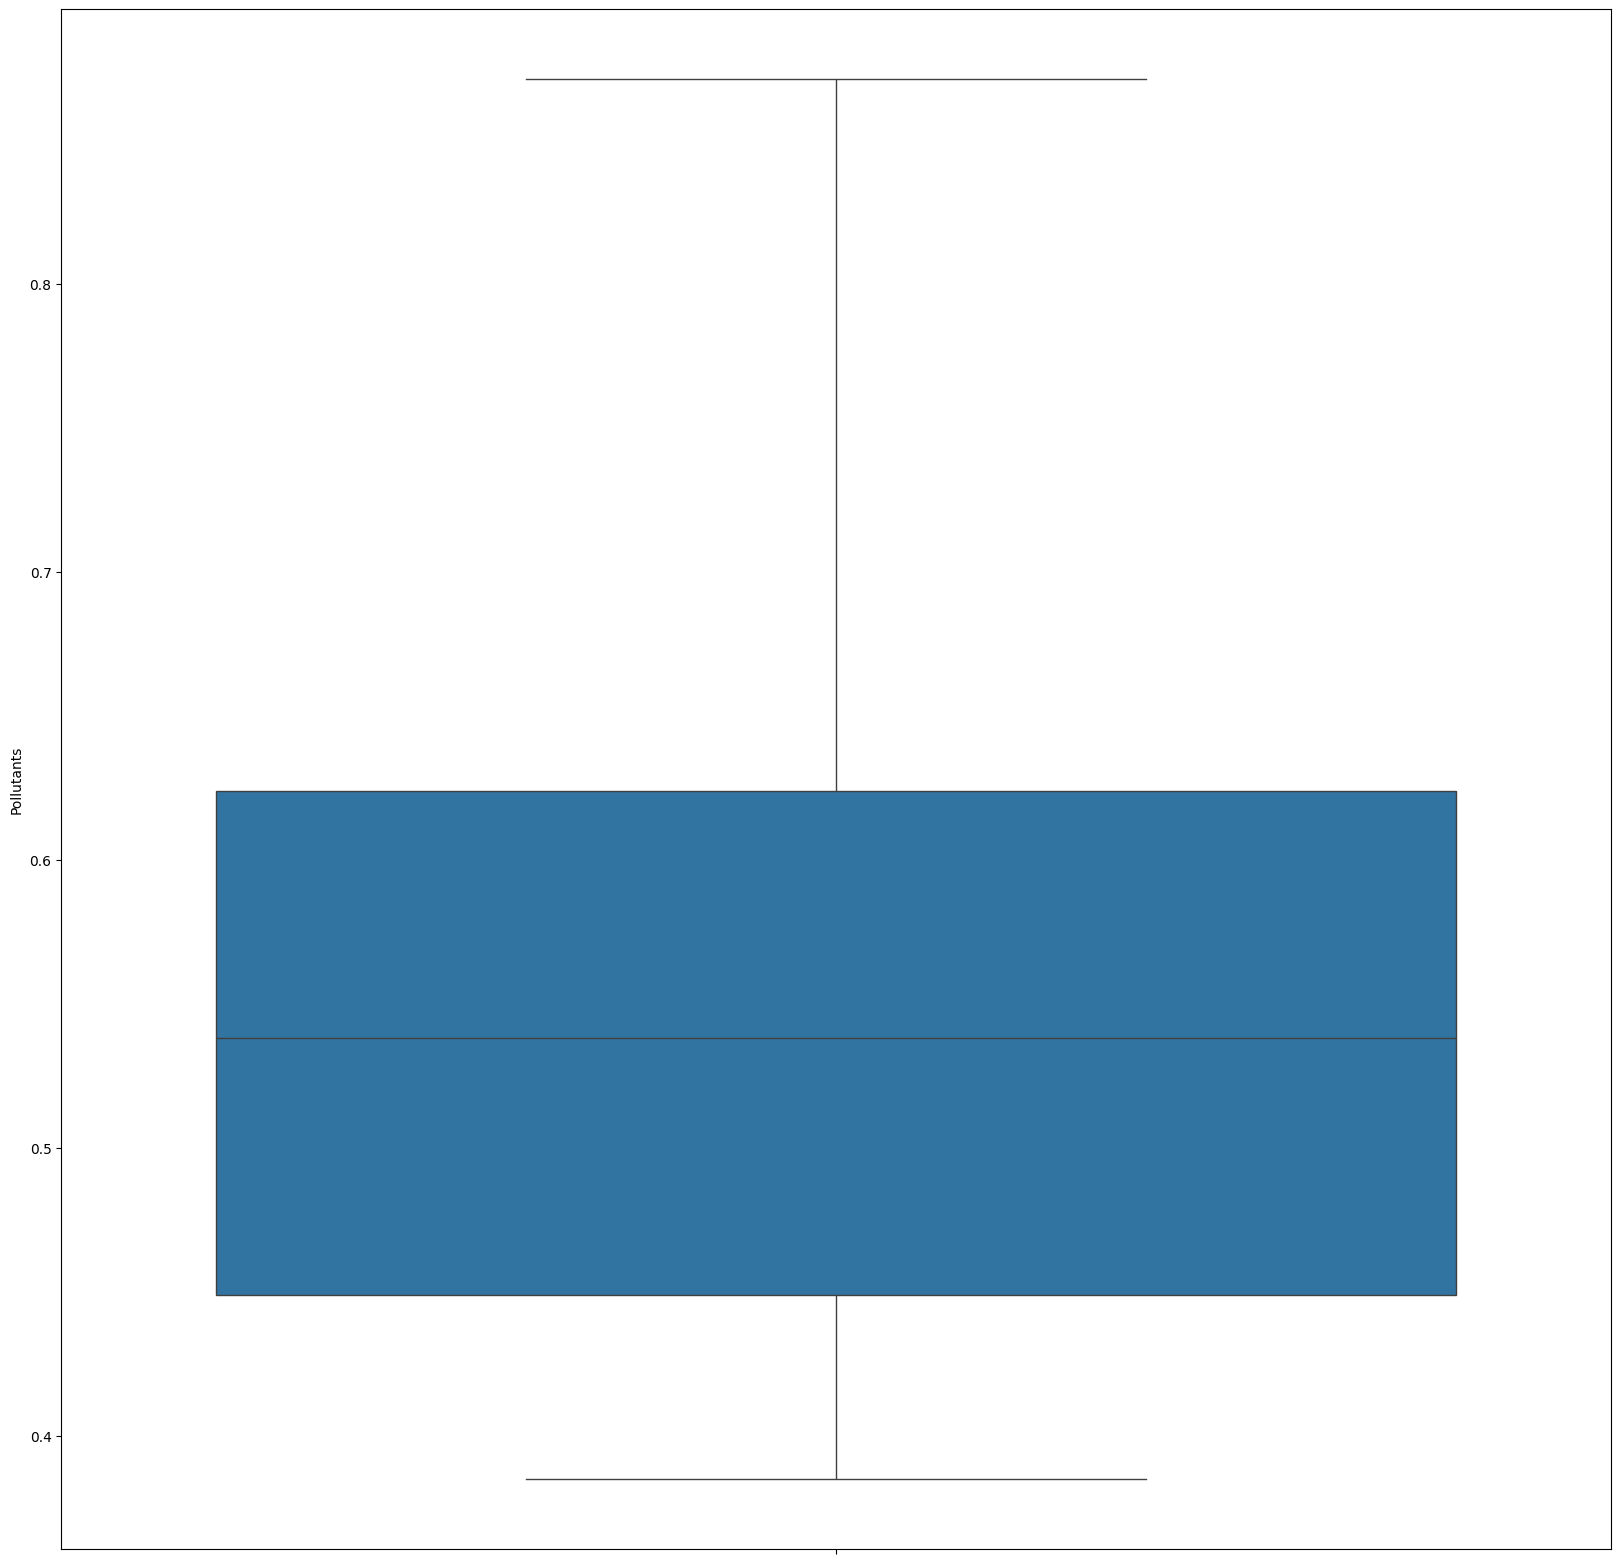

In [ ]:
fig= plt.subplots(figsize=(20, 20))
sns.boxplot(df['Pollutants'],
           flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 8})
plt.show()

**Response.**

**Variables with outliers**
1.   Rooms
2.   Distance_Office
3.   Student_Teacher_Ratio
4.   Low_Income
5.   Price












**Rooms:** Some outliers above the top whisker have more than approximately 7 rooms. The rest of the outliers below the bottom whisker have fewer than approximately 4 rooms.
*   Keep the outliers without modifying

*   The data for Rooms is normally distributed and the range of the values is small (roughly from 3.5 to 8.8)

*   Assuming the goal of collecting the observations are to understand the entire property market, these outliers allow the model to be familiarised with the full range of large and small properties.

**However, we may remove the anomaly (ID 366 because it has lesser rooms but valued at a higher price)**

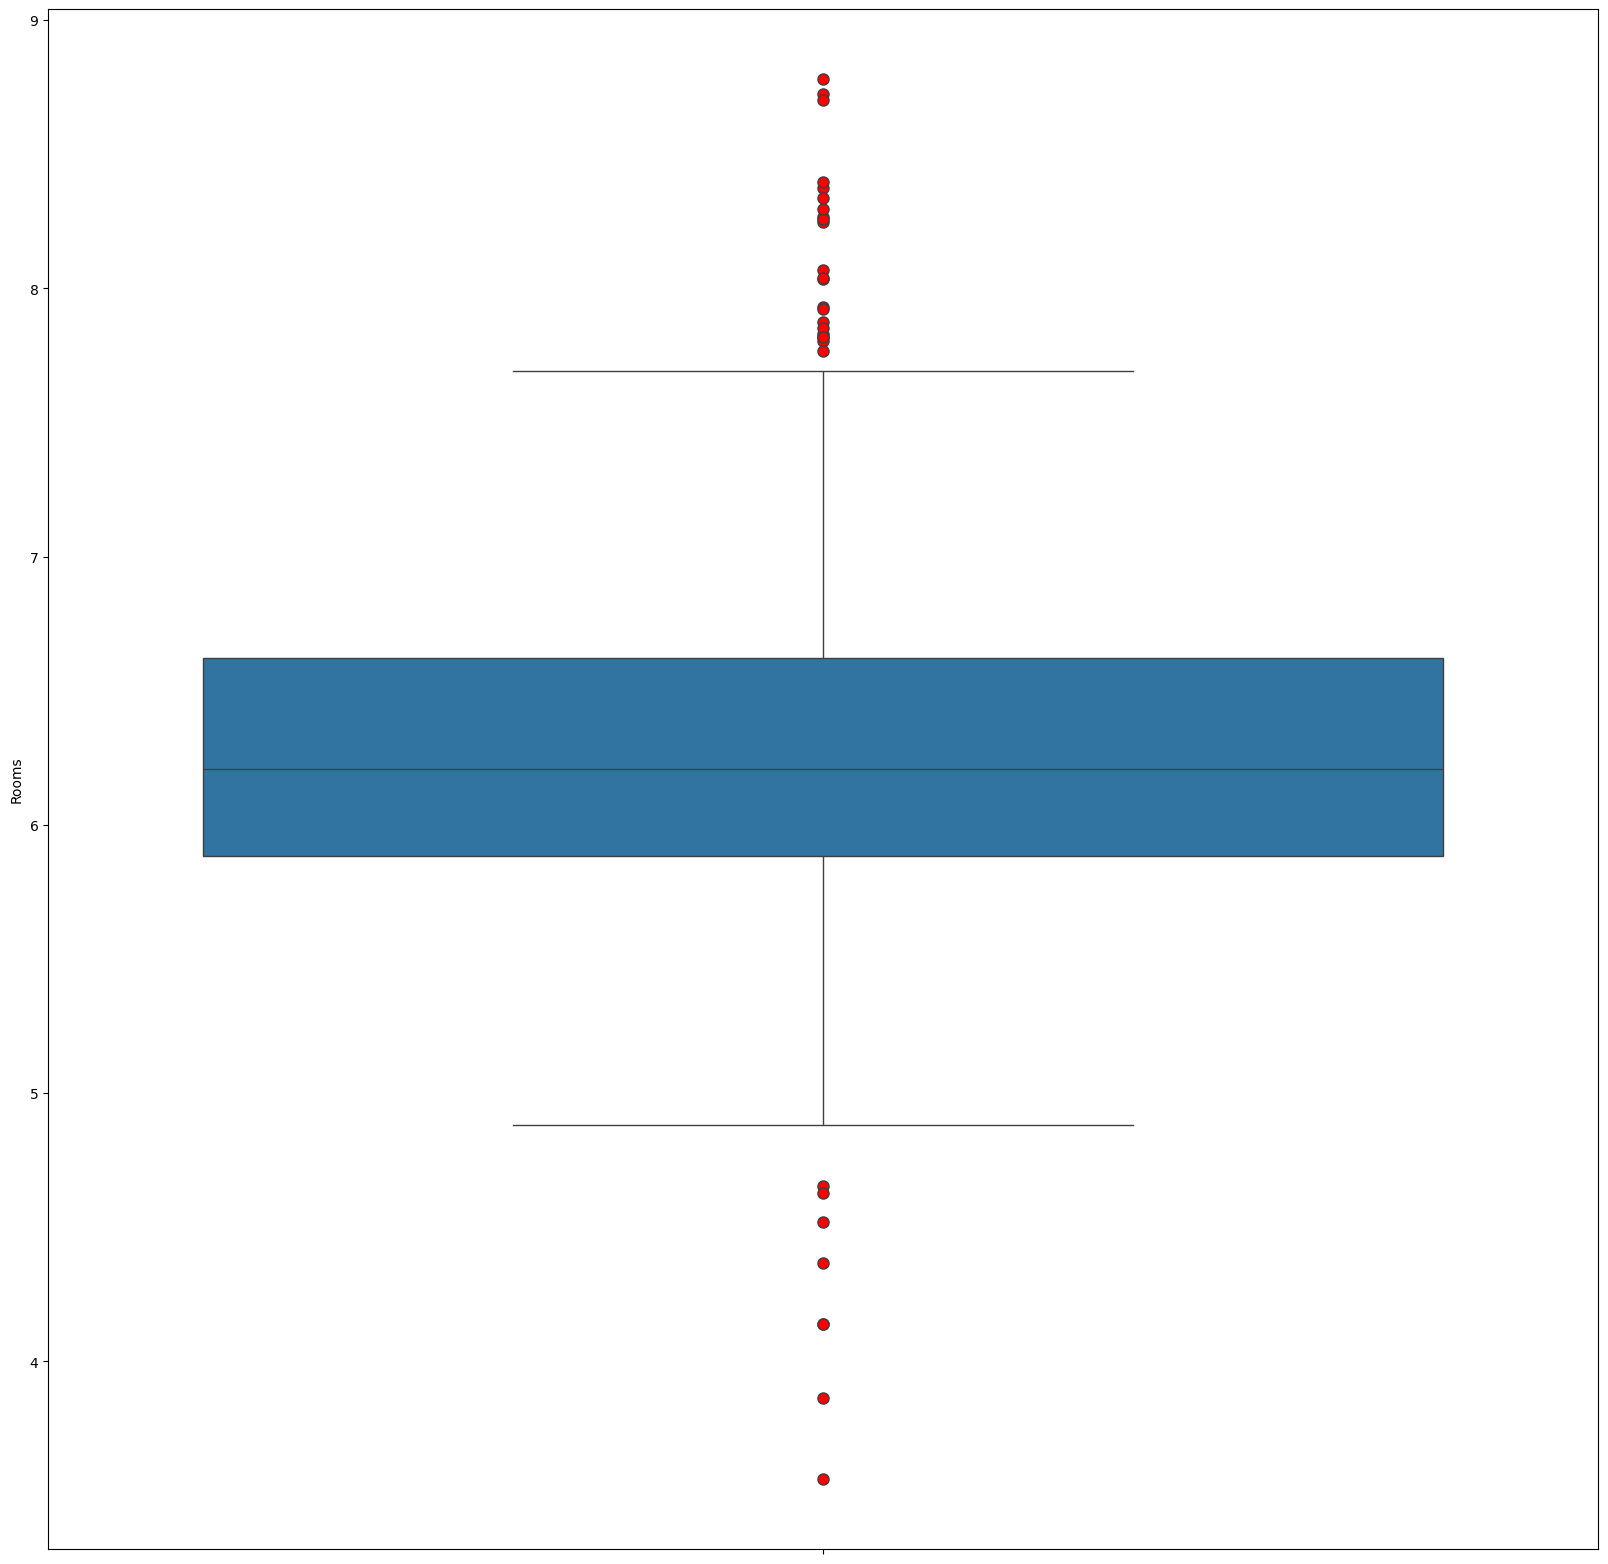

In [ ]:
#zoomed-in box plot to each variable with outliers
fig= plt.subplots(figsize=(20, 20))
sns.boxplot(df['Rooms'],
           flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 8})
plt.show()


**Distance_Office:** The outliers are above the top whisker and are higher than the 75th percentile, representing areas that are further away from business districts

*   Modify the outliers

*   Perform Log Transformation because the data for Distance_Office is right skewed and the transformation can rescale the outliers

*   Assuming the model needs to analyse properties in both city and suburban areas, we want the outliers to represent properties further away from the office


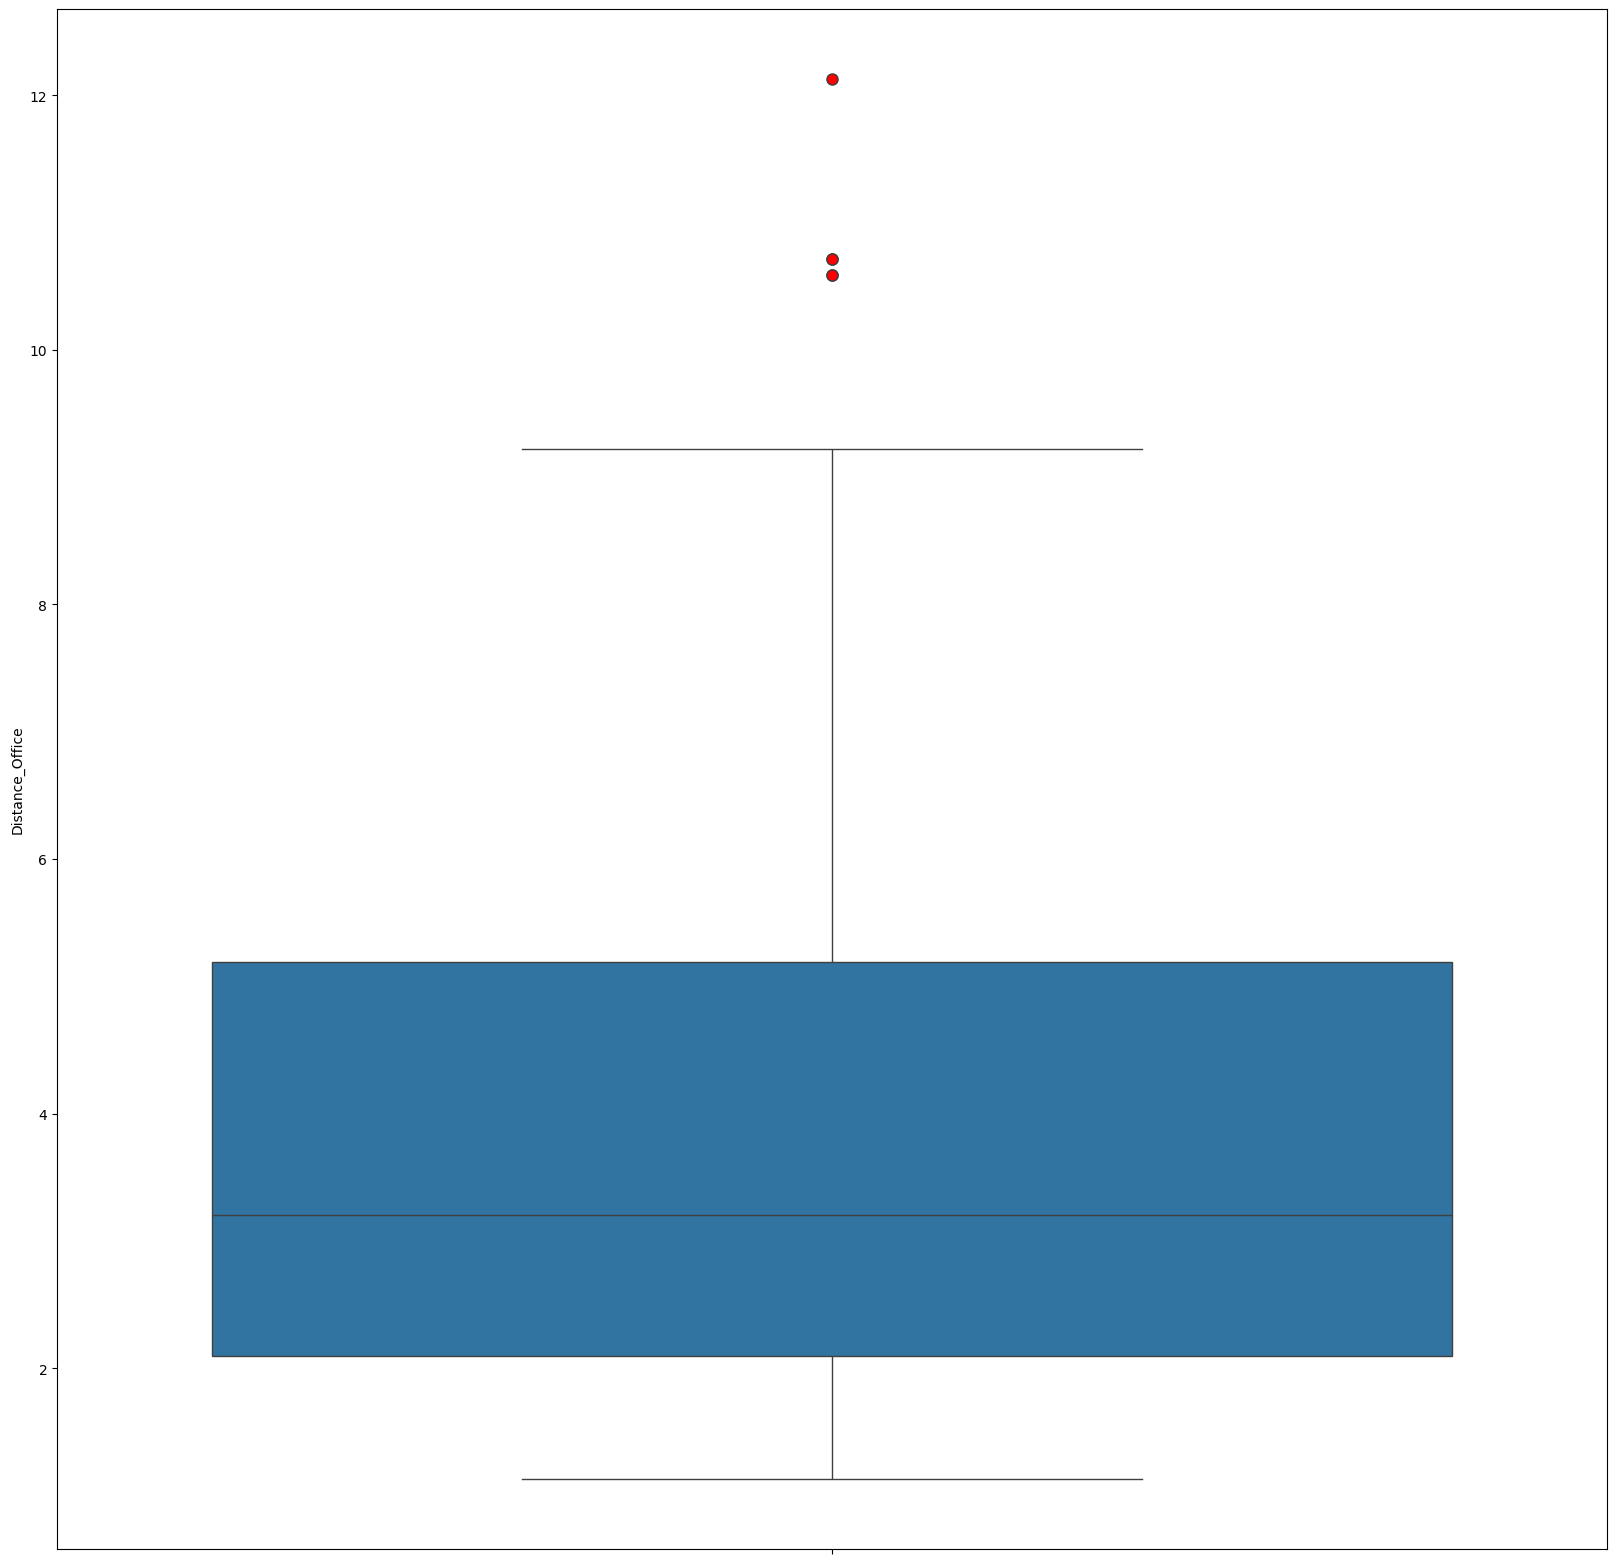

In [ ]:
fig= plt.subplots(figsize=(20, 20))
sns.boxplot(df['Distance_Office'],
           flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 8})
plt.show()

**Student_Teacher_Ratio:** The outliers are below the bottom whisker and are smaller than the 25th percentile, representing areas with better education quality because the teacher can focus on a smaller group of students
*   Keep the outliers

*   Performing Square Root transformation will help because the data for Student_Teacher_Ratio is left skewed but the skewness is slight and the variable has a very narrow range of 12 to 22.

*   Assuming the model should handle inquiries about areas with properties near schools.

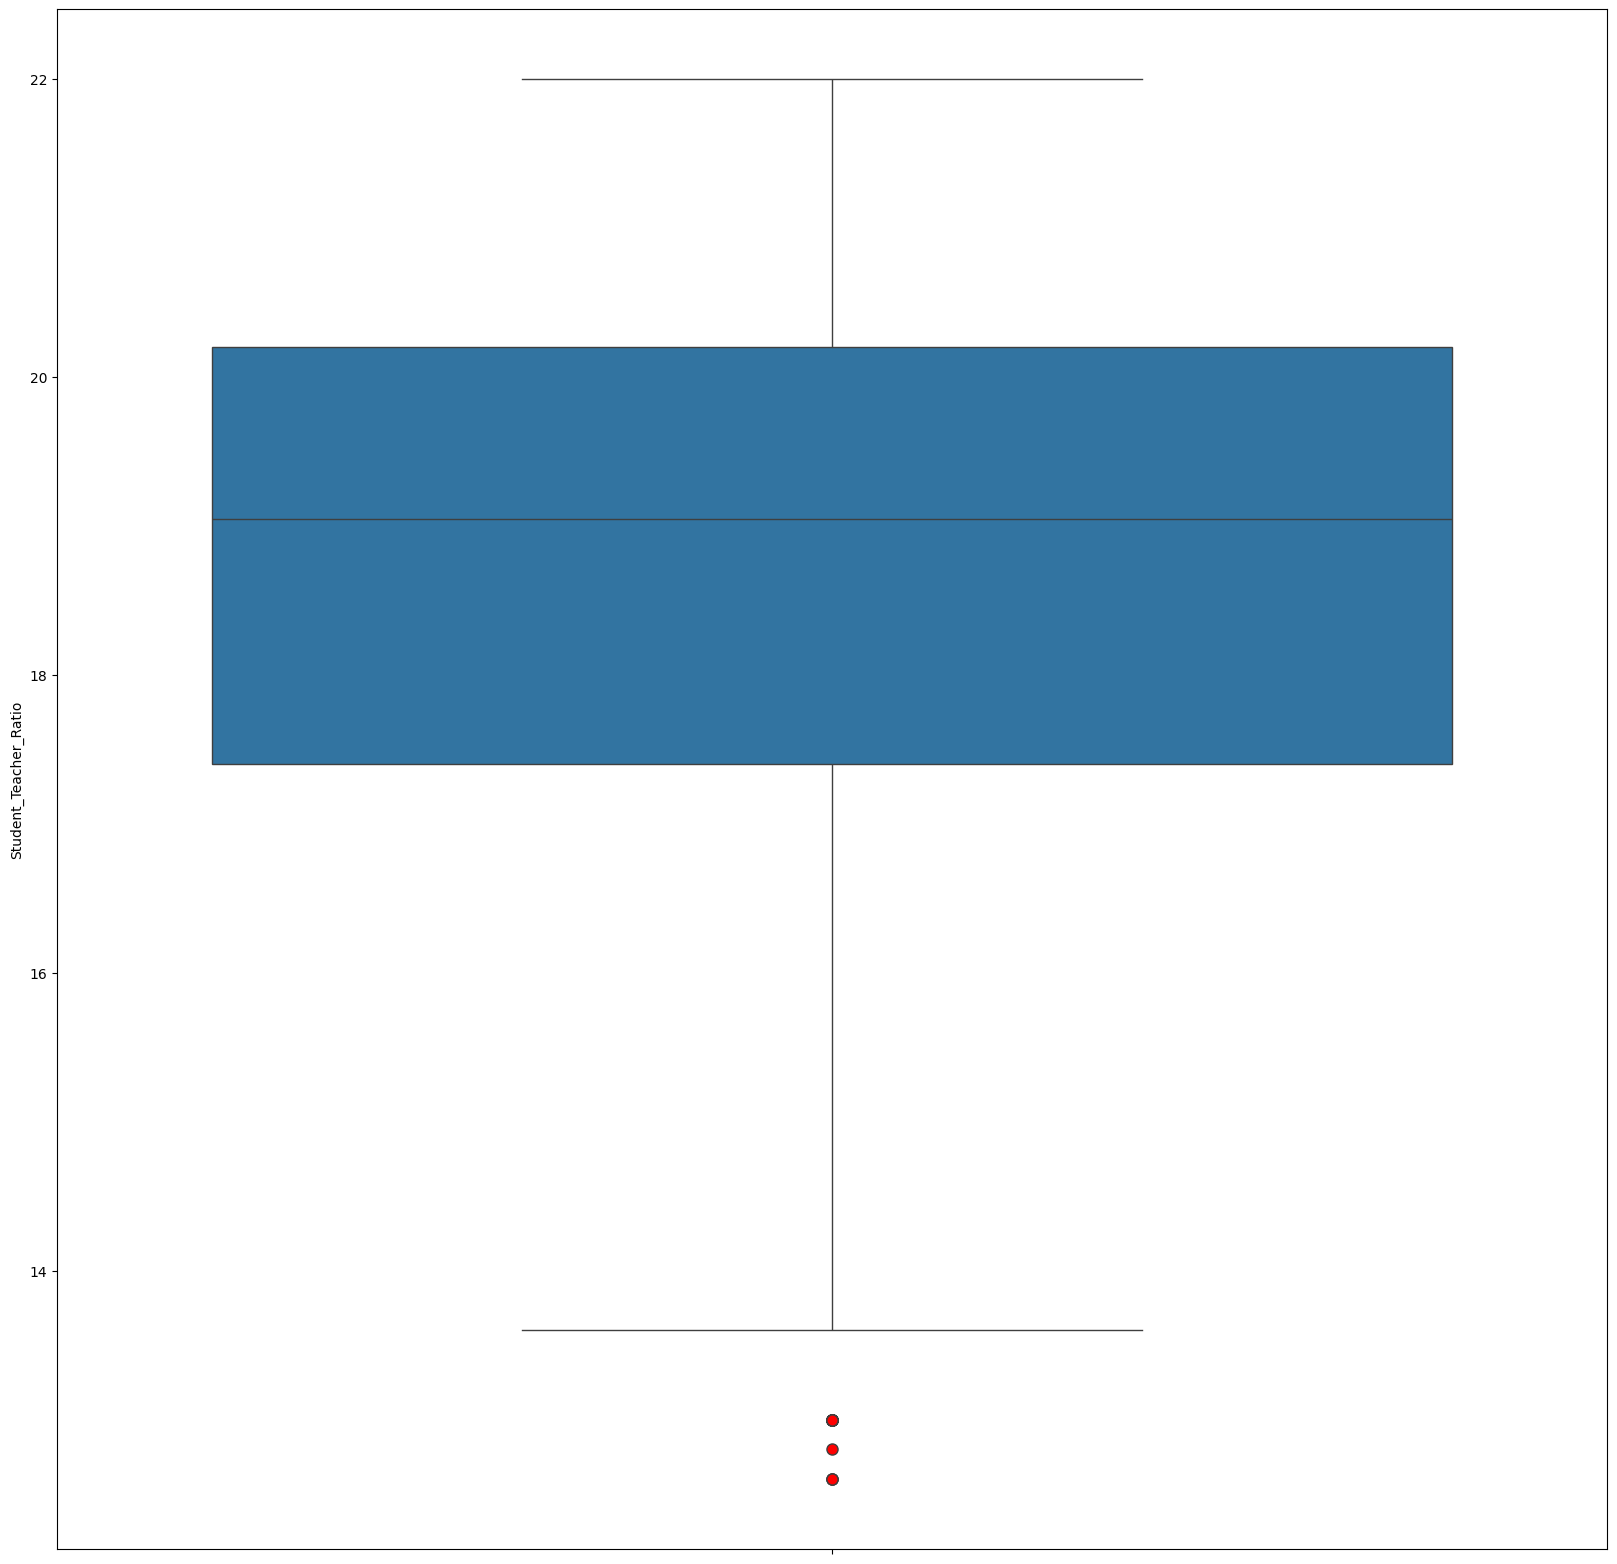

In [ ]:
fig= plt.subplots(figsize=(20, 20))
sns.boxplot(df['Student_Teacher_Ratio'],
           flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 8})
plt.show()

**Low_Income:** The outliers are above the top whisker and are higher than the 75th percentile, representing areas with more low income residents

*   Modify the outliers

*   Perform Log Transformation because the data for Low_Income is right skewed and the transformation can rescale the outliers

*   Assuming the model needs to analyse properties in areas that are less well-off.

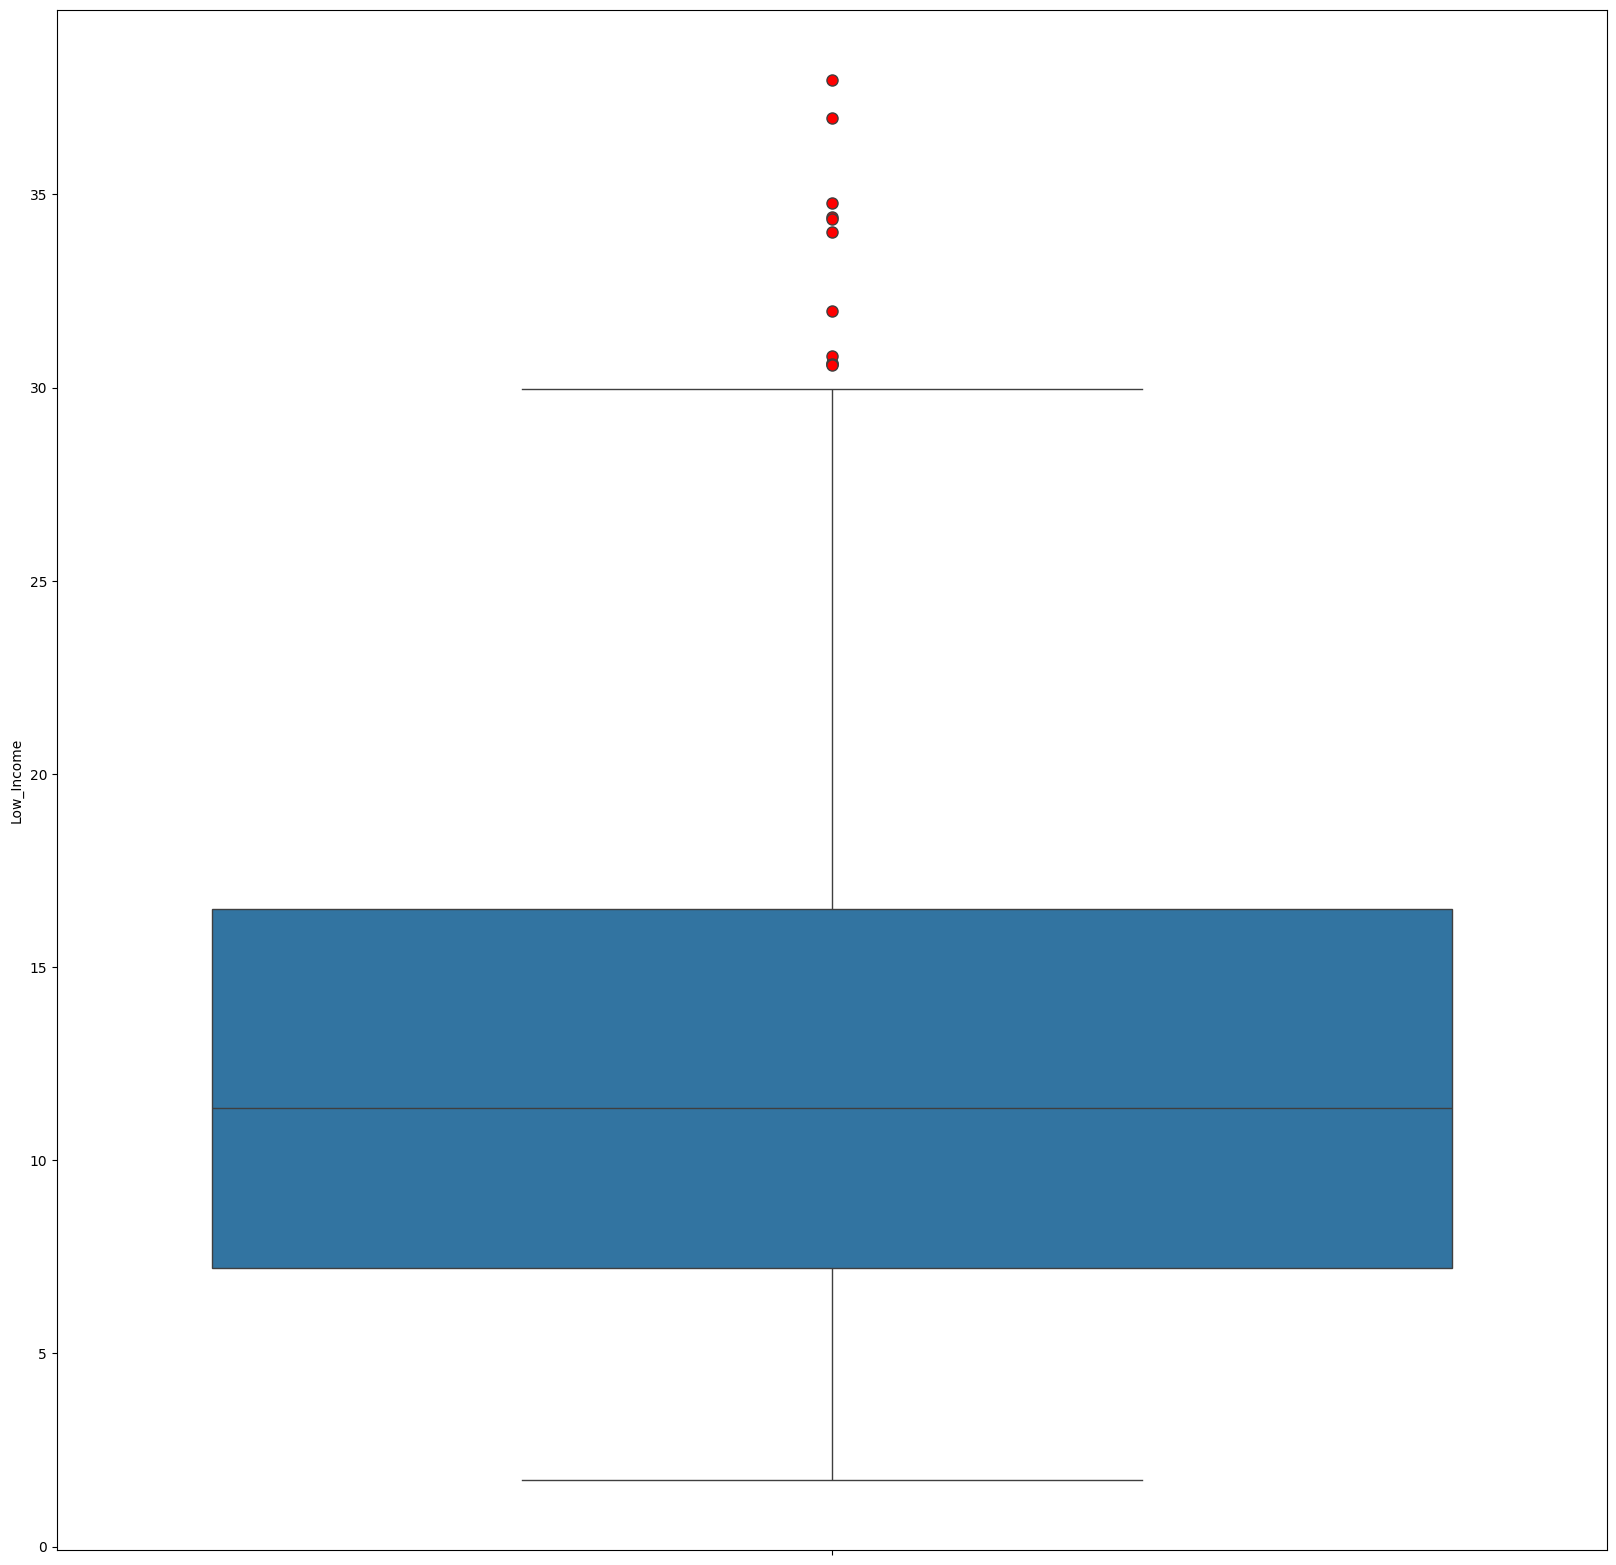

In [ ]:
fig= plt.subplots(figsize=(20, 20))
sns.boxplot(df['Low_Income'],
           flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 8})
plt.show()

**Price**:
Most outliers are located above the upper whisker, indicating areas with significantly higher property prices. A small number of outliers are observed below the lower whisker, representing more affordable properties.

The distribution of Price appears to be right-skewed, with a concentration of values around 50, while the median is approximately 21. This suggests that higher-priced properties are stretching the distribution.

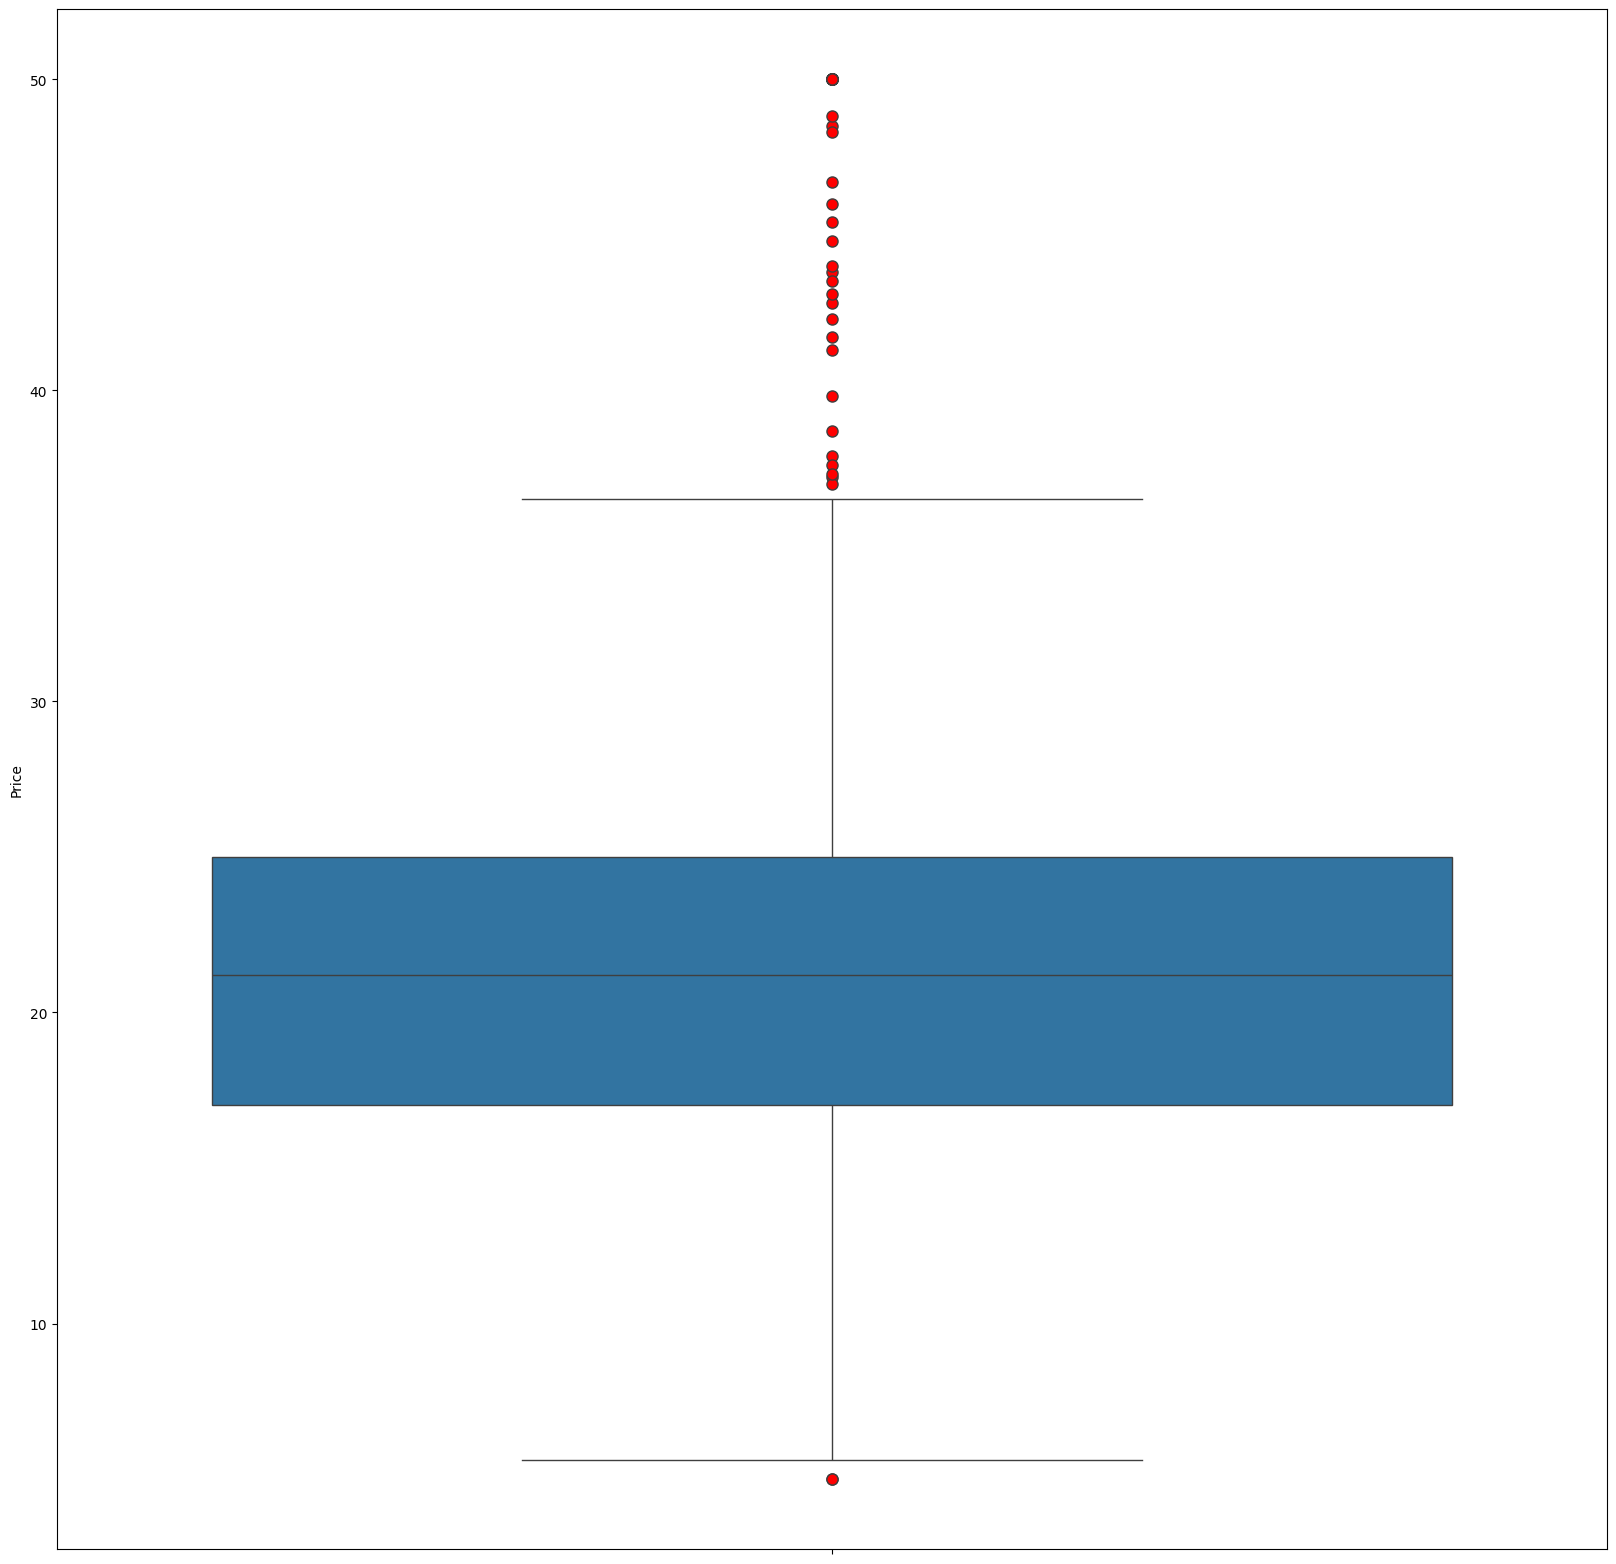

In [ ]:
fig= plt.subplots(figsize=(20, 20))
sns.boxplot(df['Price'],
           flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 8})
plt.show()

**c.** For categorical variables, perform the necessary encoding.








**Response.**

**Ordinal variables**
*   Crime_Rate
*   Residential_Area
*   Highway_Access

For ordinal variables, label encoding may be deployed to preserve meaningful ranks between the categories (High=3 > Moderate=2 > Low=1)






In [ ]:
df['Crime_Rate_Encd'] = df['Crime_Rate'].map({'Low': 0, 'Moderate': 1, 'High': 2})

df['Residential_Area_Encd'] = df['Residential_Area'].map({
    'Very Low': 0,
    'Low': 1,
    'Moderate': 2,
    'High': 3,
    'Very High': 4
})

df['Highway_Access_Encd'] = df['Highway_Access'].map({'Low': 0, 'Moderate': 1, 'High': 2})


**Nominal**
*   River
Assuming we are only looking at the definition of categories (Near and Far), they do not by themselves suggest any ranking, even though Near may suggest lower Price.

For nominal variables, dummy encoding is sufficient (Near=True=1, naturally Far=False=0)


In [ ]:
dummy_en = pd.get_dummies(df['River'],prefix='River', drop_first=True )
df = pd.concat([df, dummy_en], axis=1)

### 3.	Exploratory analysis and visualization [50% of Part I]

**a.** For each variable, provide relevant summary statistics

In [ ]:
#for numerical variables
df.describe()

,ID,Non_Retail,Pollutants,Rooms,Old_Housing,Distance_Office,Tax_Rate,Student_Teacher_Ratio,Low_Income,Price,Crime_Rate_Encd,Residential_Area_Encd,Highway_Access_Encd
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,11.138874,0.554695,6.284634,69.110474,3.795043,408.274704,18.450988,12.571640,22.532806,0.260870,0.490119,1.098814
std,146.213884,6.862644,0.115878,0.702617,28.339548,2.105710,168.496548,2.163891,6.963147,9.197104,0.506522,1.064690,0.643412
min,1.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,1.730000,5.000000,0.000000,0.000000,0.000000
25%,127.250000,5.190000,0.449000,5.885500,45.175000,2.100175,279.250000,17.400000,7.205000,17.025000,0.000000,0.000000,1.000000
50%,253.500000,9.690000,0.538000,6.208500,78.200000,3.207450,330.000000,19.050000,11.360000,21.200000,0.000000,0.000000,1.000000
75%,379.750000,18.100000,0.624000,6.623500,94.575000,5.188425,666.000000,20.200000,16.492500,25.000000,0.000000,0.000000,2.000000
max,506.000000,27.740000,0.871000,8.780000,102.000000,12.126500,711.000000,22.000000,37.970000,50.000000,2.000000,4.000000,2.000000


In [ ]:
# more relevant stats for categorical variables
df.describe(include='object')

,Crime_Rate,Residential_Area,River,Highway_Access
count,506,506,506,506
unique,3,5,2,3
top,Low,Very Low,Far,Moderate
freq,390,384,472,292


**Response.**

**b.** For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

#Categorical Variables

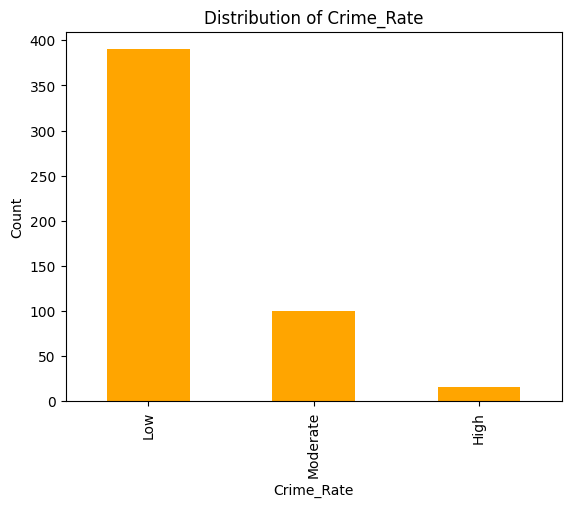

Crime_Rate
Low         77.075099
Moderate    19.762846
High         3.162055
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
plt.figure()
df["Crime_Rate"].value_counts().plot(kind="bar", color="orange")
plt.title("Distribution of Crime_Rate")
plt.xlabel("Crime_Rate")
plt.ylabel("Count")
plt.show()
print(df["Crime_Rate"].value_counts(normalize=True) * 100)


The distribution is heavily skewed, with "Low" as the dominant category at 77.1%, "Moderate" at 19.8%, and "High" at 3.2%. The majority of neighbourhoods in this dataset are low-crime areas, signifying that the estates are mostly safe.

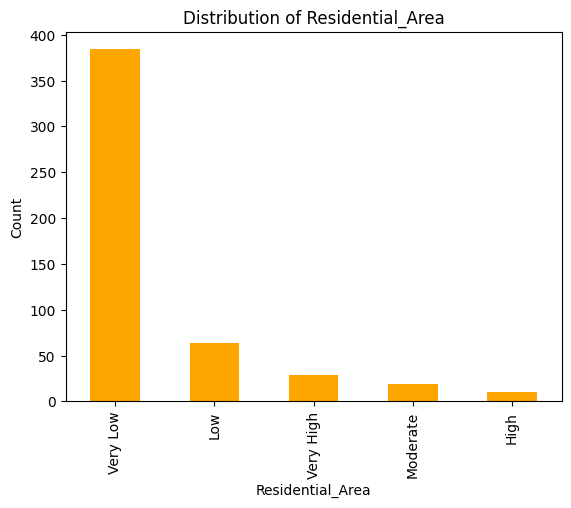

Residential_Area
Very Low     75.889328
Low          12.648221
Very High     5.731225
Moderate      3.754941
High          1.976285
Name: proportion, dtype: float64


In [ ]:
plt.figure()
df["Residential_Area"].value_counts().plot(kind="bar", color="orange")
plt.title("Distribution of Residential_Area")
plt.xlabel("Residential_Area")
plt.ylabel("Count")
plt.show()
print(df["Residential_Area"].value_counts(normalize=True) * 100)


In the region, 75.9% of the towns have residential areas below 25000 square feet, as data is heavily skewed towards "Very Low".

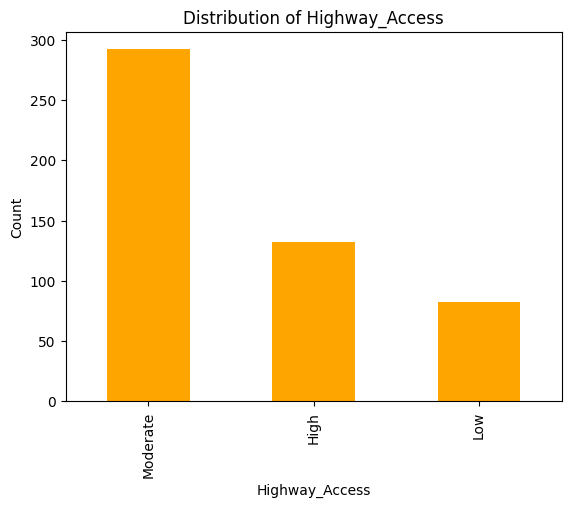

Highway_Access
Moderate    57.707510
High        26.086957
Low         16.205534
Name: proportion, dtype: float64


In [ ]:
plt.figure()
df["Highway_Access"].value_counts().plot(kind="bar", color="orange")
plt.title("Distribution of Highway_Access")
plt.xlabel("Highway_Access")
plt.ylabel("Count")
plt.show()
print(df["Highway_Access"].value_counts(normalize=True) * 100)


In the region, 57.7% of the towns have moderate access to major highways, while 26.1% have high access and the remaining 16.2% have low access.

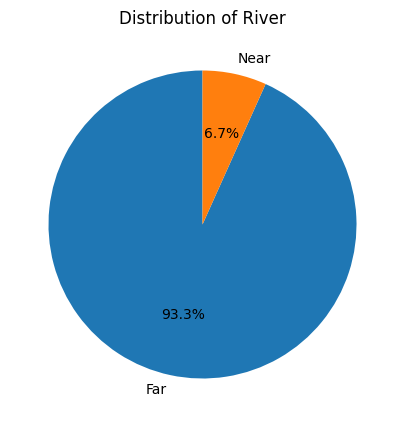

In [ ]:
plt.figure(figsize=(5,5))
df["River"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of River")
plt.ylabel("")
plt.show()

Highly imbalanced. River is a binary category with only "Near" and "Far". Most neighbourhoods are far from rivers.

#Numerical Variables

In [ ]:
num_cols = df.select_dtypes(include='number').columns.drop("ID")

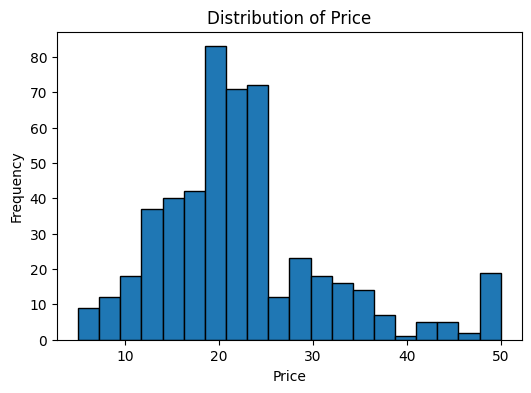

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Price"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## **Key Observation:**
Most values concentrated between \$17000 and \$25000.
The mean of \$22,533 exceeds the median of \$21,200, pulled up by a few expensive neighbourhoods reaching up to \$50,000.
A few neighbourhoods at the lower end go as low as \$5,000.

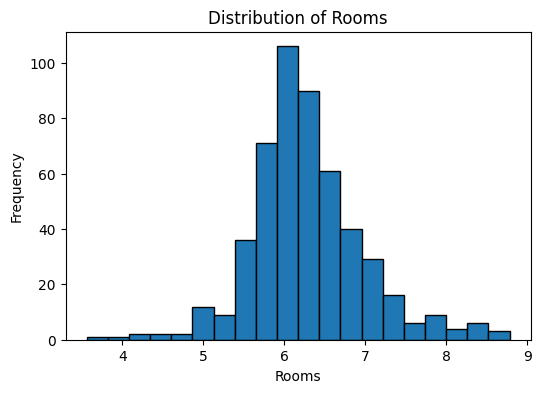

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Rooms"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Rooms")
plt.xlabel("Rooms")
plt.ylabel("Frequency")
plt.show()

## **Key Observation:**
Approximately normally distributed, centered around 6.2 rooms with a tight spread. The peak of the histogram is in the 5.9–6.2 range. There are a few neighbourhoods with notably high (up to 8.8) or low (down to 3.6) room counts, but the overall range is narrow.

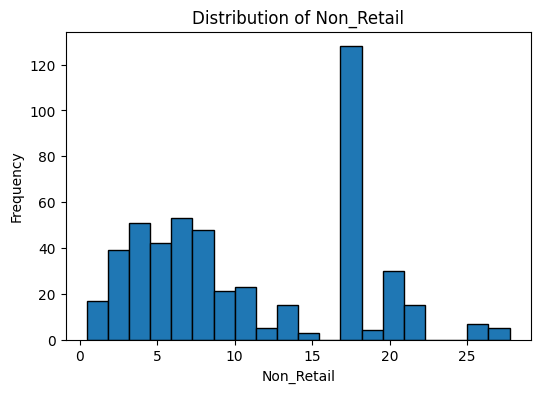

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Non_Retail"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Non_Retail")
plt.xlabel("Non_Retail")
plt.ylabel("Frequency")
plt.show()

## **Key Observation:**
Mildly right-skewed but with a notable spike at the 17-18% range (128 observations), suggesting a cluster of neighbourhoods with high industrial land use. The spike seems to be an anomaly, as there is higher frequency for lower values of non-retail in neighbourhoods.


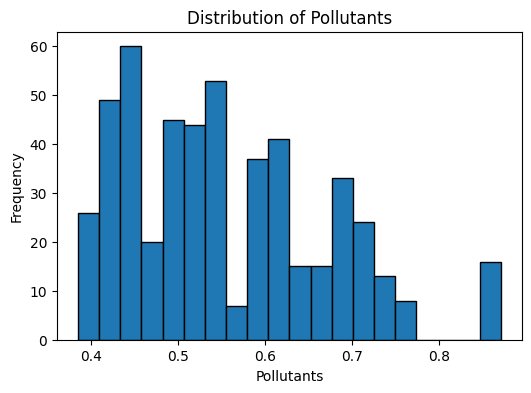

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Pollutants"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Pollutants")
plt.xlabel("Pollutants")
plt.ylabel("Frequency")
plt.show()

## **Key Observation:**
Right-skewed, with most values concentrated at the lower end around 0.4–0.5. The distribution tapers off gradually towards the end, but there is a small spike at around 0.87, indicating that while most neighbourhoods have moderate pollution, some have noticeably higher concentrations.

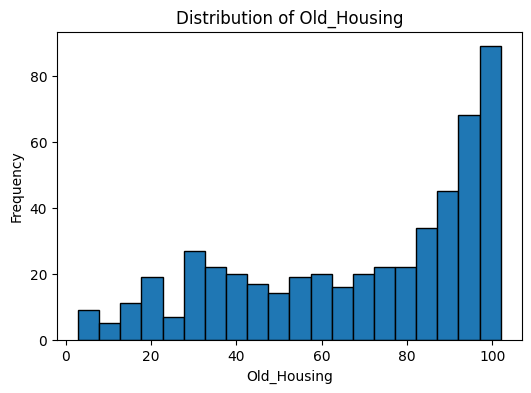

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Old_Housing"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Old_Housing")
plt.xlabel("Old_Housing")
plt.ylabel("Frequency")
plt.show()

## **Key Observation:**
 Left-skewed, with the highest frequency at the upper end (97–102%), meaning a large number of neighbourhoods consist almost entirely of older, unrenovated properties. The distribution has a long tail stretching down to 2.9%, representing a few areas with mostly newer housing.

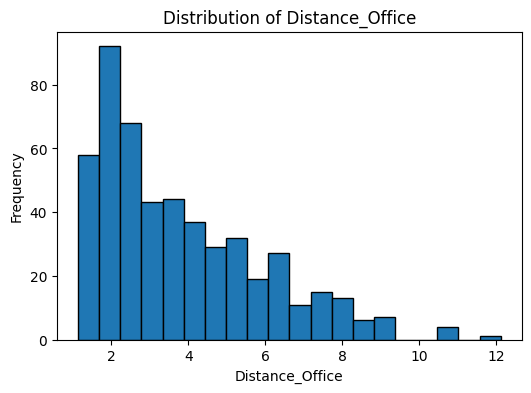

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Distance_Office"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Distance_Office")
plt.xlabel("Distance_Office")
plt.ylabel("Frequency")
plt.show()

## **Key Observation:**
Right-skewed, with the peak at 1.7–2.2 km. Most neighbourhoods are relatively close to business districts, but there is a long tail extending to 12.1 km. This skewness was noted in Part 2b as the reason for proposing a log transformation.

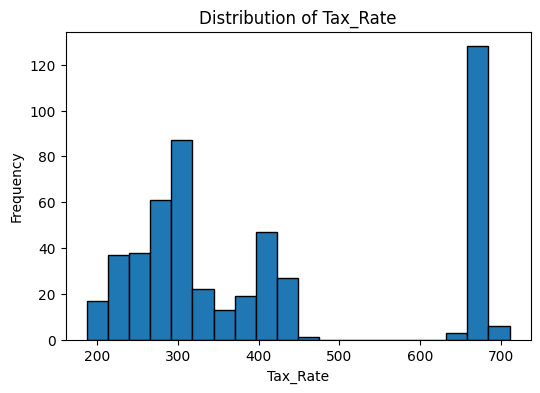

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Tax_Rate"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Tax_Rate")
plt.xlabel("Tax_Rate")
plt.ylabel("Frequency")
plt.show()

## **Key Observation:**
There is a bimodal distribution. There is one cluster of neighbourhoods in the 187–500 range and a second distinct spike around 666, which alone accounts for 125 out of 506 observations (24.7%). This suggests there may be 2 distinct tax policies in the dataset.

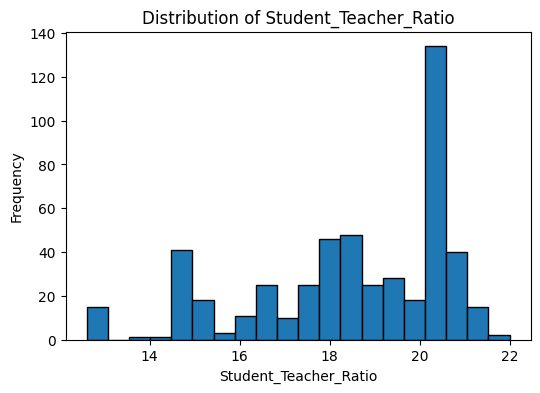

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Student_Teacher_Ratio"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Student_Teacher_Ratio")
plt.xlabel("Student_Teacher_Ratio")
plt.ylabel("Frequency")
plt.show()

## **Key Observation:**
Left-skewed, with a sharp spike at 20.2 (134 observations, 26.5% of the dataset). This heavy concentration at a single value suggests many neighbourhoods could share the same school district. Other than this, values are spread between 12.6 and 22.0.

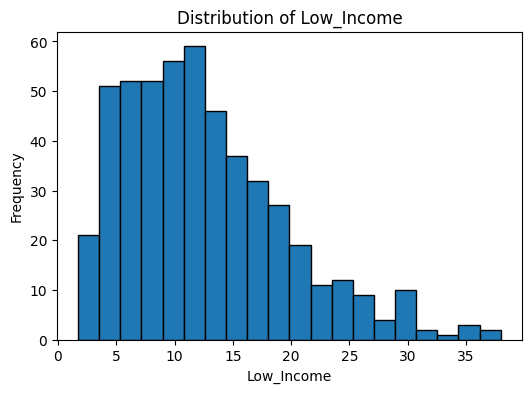

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Low_Income"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Low_Income")
plt.xlabel("Low_Income")
plt.ylabel("Frequency")
plt.show()

## **Key Observation:**
Right-skewed, with most values in the 5–17% range and a tail extending to 38%. The mean (12.6%) is higher than the median (11.4%), indicating that a smaller number of neighbourhoods with very high proportions of low-income residents pull the average up.

**Response.**

**c.** Perform bi-variate analysis on the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables. Use appropriate statistical methods and/or visualizations.

**Response.**

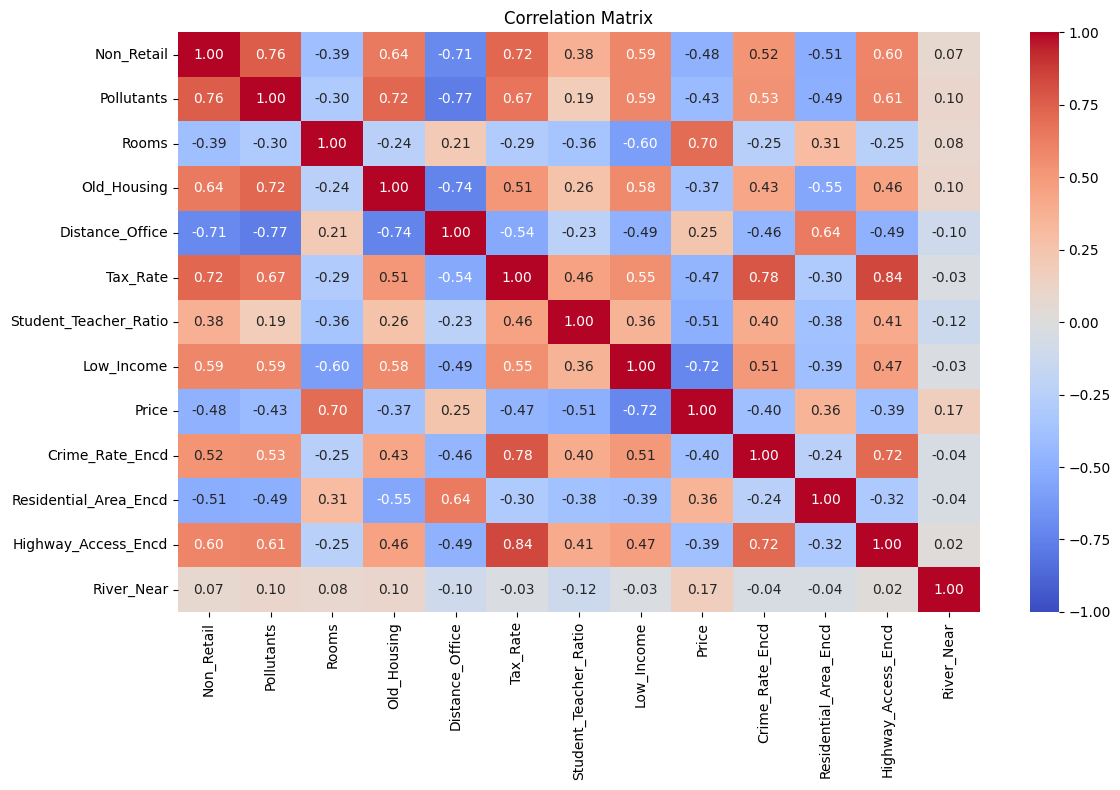

In [ ]:
import seaborn as sns

# remove ID and original categorical variables (keep only encoded versions)
cols_to_drop = ['ID', 'Crime_Rate', 'Residential_Area', 'Highway_Access', 'River']
df_corr = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# select numeric columns (catch dummy col frm River_Near)
numeric_df = df_corr.select_dtypes(include=['number', 'bool'])

# compute correlation matrix
corr_matrix = numeric_df.corr()

# plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## **Overview from Correlation Heatmap:**

The two strongest correlations with Price are Low_Income (r = −0.74) and Rooms (r = 0.70). Moderate negative correlations exist with Student_Teacher_Ratio (r = −0.50), Non_Retail (r = −0.54), Tax_Rate (r = −0.), and Pollutants (r = −0.43). Distance_Office has a relatively weak positive correlation with Price (r = 0.25).

Other than Price, there are also strong inter-correlations among the independent variables. Pollutants vs Distance_Office (r = −0.77) and Non_Retail vs Pollutants (r = 0.76).

In [ ]:
# Removed as per user request due to high correlation with Price (r=0.70).

In [ ]:
# Removed as per user request due to high correlation with Price (r=-0.74).

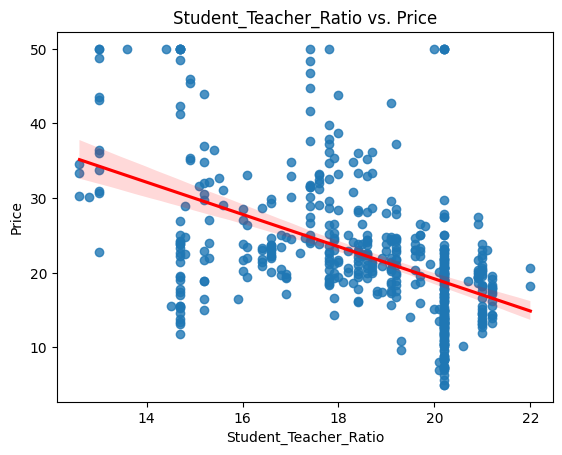

In [ ]:
sns.regplot(x="Student_Teacher_Ratio", y="Price", data=df, line_kws={"color": "red"})
plt.title("Student_Teacher_Ratio vs. Price")
plt.show()

Price and Student_Teacher_Ratio exhibit a moderate negative relationship (r ≈ −0.51). Areas with higher student–teacher ratios tend to have lower housing prices. This may suggest that neighbourhood characteristics related to school resources or population density are associated with property values.

However, there is wide variability of data points from the best-fit line as seen in the graph. This suggests that Student_Teacher_Ratio alone is not the most accurate predictor of housing prices.

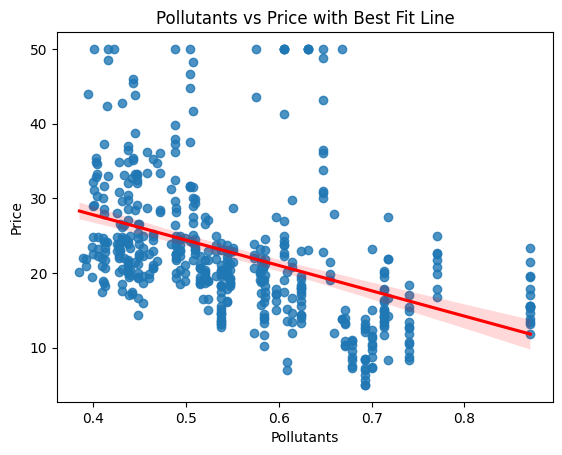

In [ ]:
sns.regplot(x="Pollutants", y="Price", data=df, line_kws={"color": "red"})
plt.title("Pollutants vs Price with Best Fit Line")
plt.show()

## **Key Observation:**

Price (y-axis) and Pollutants (x-axis) have moderate negative linear relationship (r=-0.43). Areas with higher pollutant concentrations tend to have lower housing prices, suggesting that environmental quality may influence property values.

The relationship between Pollutants and Price appears weaker than that observed between Price and Low_Income (r = -0.72). This suggests that neighbourhood socioeconomic characteristics may be more strongly associated with housing prices than pollution levels in this dataset.

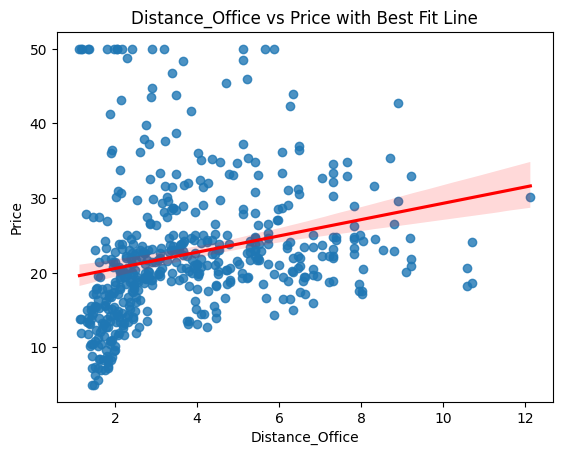

In [ ]:
sns.regplot(x="Distance_Office", y="Price", data=df, line_kws={"color": "red"})
plt.title("Distance_Office vs Price with Best Fit Line")
plt.show()

## **Key Observation:**

Price (y-axis) and Distance_Office (x-axis) have a weak positive linear relationship (r=0.25). This is interesting because a common assumption is that homes closer to offices would command higher premiums – they afford occupants more convenience and less travelling time to work.

A possible explanation is that pollution is negatively correlated with distance from office (see Correlation Matrix), suggesting that office areas are associated with more pollution. From the Pollutant vs Prices graph, we also know that polluted areas are associated with lower housing prices. Thus, the level of pollution could also negatively influence housing prices closer to office.

Still, the gradient of the line is gentle. This indicates that the positive correlation, though unexpected, is small.

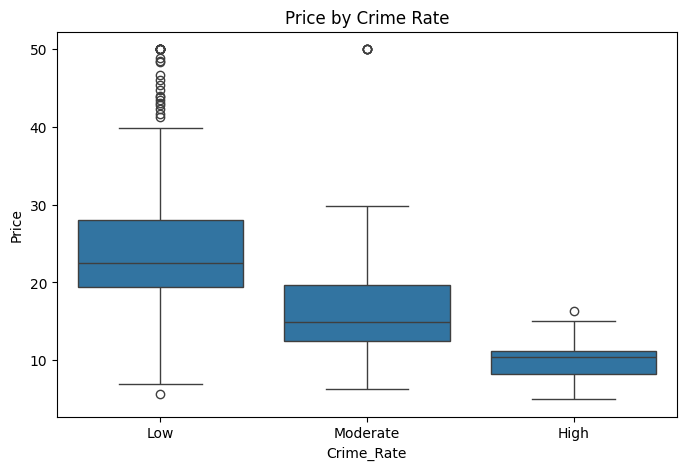

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Crime_Rate", y="Price", data=df, order=["Low", "Moderate", "High"])
plt.title("Price by Crime Rate")
plt.show()

## **Key Observation:**

The boxplot shows a clear negative relationship between crime rate and housing prices. Neighbourhoods with low crime rates have the highest median housing price (≈\$22k), followed by moderate crime areas (≈\$15k) and high crime areas (≈\$10k). This is expected as high crime-rate areas may be perceived as less livable, which could be associated with lower housing prices.

Low-crime neighbourhoods have highest variance in prices. It has the largest interquartile range. We can see that the median is of the low-crime neighbourhoods is slightly nearer to the lower quartile, though there are many high-price (above ≈\$40k) outliers as well. This could be because there tend to be more luxury housing in low-crime neighbourhoods as compared to areas with higher crime rates.

In contrast, high-crime areas show a narrower price distribution (as they have the smallest interquartile range), indicating that housing prices are consistently lower in those neighbourhoods.

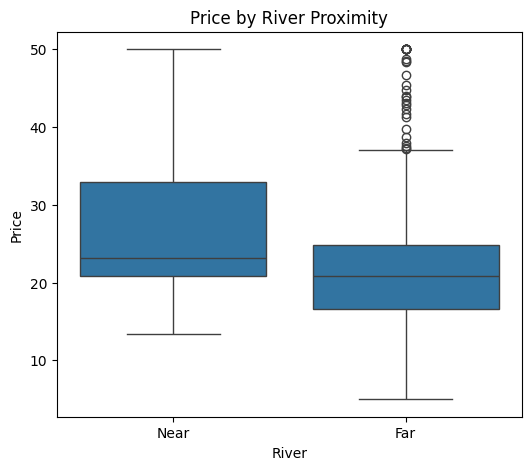

In [ ]:
# Price by River proximity
plt.figure(figsize=(6,5))
sns.boxplot(x="River", y="Price", data=df, order=["Near", "Far"])
plt.title("Price by River Proximity")
plt.show()

## **Key Observation:**

Neighbourhoods near a river have a higher median price (≈\$23k) compared to those far from a river (≈\$21k). The "Near" group also has much more variance, as can be seen from the larger interquartile range. The median for prices under the "Near" group seems to be quite near to the lower quartile, suggesting the data is right-skewed. But, the long upper whisker reaches ≈\$50k, showing that the top 25% of homes near rivers has a wide price range.

The "Far" group exhibits several high-price outliers above ≈$37k, indicating that a few properties far from rivers are priced substantially higher than the typical range.

However, with only 34 "Near" observations versus 472 "Far", this comparison should be interpreted cautiously.

Moreover, while river proximity does appear to be associated with slightly higher prices, the median value for the "Near" group is only slightly higher than that of the "Far" group. This suggests that river proximity alone may not be a strong driver of housing price.


# Part II: Modeling [12% of final grade]

---


### 1. Problem formulation [15% of Part II]

**a.** Formulate one regression problem and one classification based on the dataset, in **no more than 50 words**.

Regression: predict Price — a continuous variable representing median home value in $1,000s — using 13 neighbourhood features including Rooms, Low_Income, and Pollutants.

Classification: predict Crime_Rate (Low, Moderate, or High) from 13 environmental and structural features, excluding Price.

**b.** State which problem (regression or classification) you would be investigating and why, in **no more than 20 words**.


Regression: Price has strong quantitative relationships with multiple features, directly guiding model choice. Crime rate sample also has heavy class imbalance which hurts classification modelling.

**c.** Clearly specify the dependent variable you are predicting, and its significance, in **no more than 20 words**

Dependent variable is Price. It directly quantifies neighbourhood desirability, informing homebuyers, sellers, and urban policymakers.

# 2. Model training [30% of Part II]



**a.** Perform feature selection. For each variable, decide if you want to include it as a feature and provide a justification. You may leverage on your analysis in Part I: EDA and/or perform additional analysis.

**Response.**



In [ ]:
corr = df.corr(numeric_only=True)
corr_price = corr["Price"].sort_values(ascending=False)

corr_price = corr_price.drop("Price")
corr_price = corr_price.drop("ID")
corr_price

,Price
Rooms,0.695360
Residential_Area_Encd,0.357607
Distance_Office,0.249929
River_Near,0.168466
Old_Housing,-0.368866
Highway_Access_Encd,-0.386146
Crime_Rate_Encd,-0.395709
Pollutants,-0.427321
Tax_Rate,-0.468582
Non_Retail,-0.482775


# Remove Features With High Multicollinearity
Based on the correlation heatmap in Part I, several independent variables exhibit strong inter-correlations **(|r| ≥ 0.7 or |r| ≤ -0.7)**, indicating potential multicollinearity.

Multicollinearity is problematic because highly correlated features provide redundant information, making it difficult for the model to distinguish the individual effect of each variable. This can lead to unstable coefficient estimates, where small changes in the data cause large fluctuations in model parameters.

In linear models such as Linear Regression, multicollinearity can also inflate the variance of coefficients, reducing their reliability and interpretability. As a result, the model may overfit the training data and perform worse on unseen data.

Therefore, removing or reducing highly correlated features helps to improve model stability, interpretability, and generalisation performance.



#Handling Multicollinearity

### **1. Infrastructure & Urban Development Variables**

The following variables exhibit strong correlations:

* **Tax_Rate and Highway_Access_Encd (r = 0.84)**
* **Tax_Rate and Crime_Rate_Encd (r = 0.78)**
* **Highway_Access_Encd and Crime_Rate_Encd (r = 0.72)**

These variables capture **similar underlying information related to infrastructure and urban development**. To reduce redundancy, **Tax_Rate is retained**, while **Highway_Access_Encd** and **Crime_Rate_Encd** are removed.

### **2. Location & Environmental Factors**

The following correlations are observed:

* **Pollutants and Distance_Office (r = −0.77)**
* **Non_Retail and Pollutants (r = 0.76)**
* **Non_Retail and Distance_Office (r = −0.71)**

These variables are closely related, as **areas further from office hubs tend to have lower pollution levels and different land use characteristics**. To address multicollinearity, **Pollutants is retained** due to its **stronger relationship with Price**, while **Distance_Office** and **Non_Retail** are removed.

### **3. Housing & Location Interaction**

Additional correlations include:

* **Old_Housing and Distance_Office (r = −0.74)**
* **Old_Housing and Pollutants (r = 0.72)**

These relationships reinforce that **Distance_Office and Pollutants belong to the same correlated cluster**. Since **Pollutants is already retained**, **Distance_Office is removed** to avoid redundancy.


# Remove those variables categorical variables original column

In [ ]:
df = df.drop(columns=[
    "Crime_Rate",
    "Residential_Area",
    "Highway_Access",
    "River"
])

In [ ]:
features_to_drop = [
    "Highway_Access_Encd",
    "Crime_Rate_Encd",
    "Distance_Office",
    "Non_Retail",
    "River_Near"#removed due to weak relationship with Price

]

clean_df = df.drop(columns=features_to_drop)

# Data Transformation

Selected variables, including Low_Income and Price, were log-transformed to reduce right skewness, while Student_Teacher_Ratio was square root transformed to stabilise variance. These transformations improve linearity, reduce heteroscedasticity, and enhance the suitability of the data for linear regression.

In [ ]:
import numpy as np

# Replace original columns with transformed versions
clean_df['Log_Price'] = np.log(clean_df['Price'])
clean_df['Log_Low_Income'] = np.log(clean_df['Low_Income'])
clean_df['Sqrt_Student_Teacher_Ratio'] = np.sqrt(clean_df['Student_Teacher_Ratio'])

#drop the original cols so that only the transformed versions remain
clean_df = clean_df.drop(columns=['Low_Income', 'Student_Teacher_Ratio'])

**b.** Split the dataset into train and test sets. Describe how you split step by step.



**Response.**



# Dataset Splitting (80:20 Train-Test Split)

In [ ]:
from sklearn.model_selection import train_test_split

# Step 1: Define features (X) and target (y)
# Remove ID and BOTH Price + Log_Price from features (to avoid leakage)
X = clean_df.drop(["Price", "Log_Price", "ID"], axis=1)

# Use Log_Price as target
y = clean_df["Log_Price"]

# Step 2: Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 3: (Optional sanity check)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (404, 7)
X_test shape: (102, 7)
y_train shape: (404,)
y_test shape: (102,)


**c.** State the model(s) you will train, and explain your choice(s), in **no more than 50 words per model**. You only need to
train one model, but if you do train more models, limit yourself to no more than three---Grading is based on the validity and soundness of your model, rather than the quantity.

**Response.**



We train two models: Linear Regression and Random Forest Regressor. See justifications below.

**d.** For each model, perform the training, and report the trained parameters and the training scores, if applicable.

##Linear regression model

Linear Regression is selected to model the linear relationship between the predictor variables and the continuous response variable, Price. Given the observed correlations in EDA, it is appropriate for estimating effect sizes and assessing the significance of predictors under the assumption of linearity and independence.

**Response.**



In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("LR Training R²:", model.score(X_train, y_train))
print("LR Intercept:", model.intercept_)
print("\nLR Coefficients:")
print(pd.Series(model.coef_, index=X_train.columns))

LR Training R²: 0.7261247556322147
LR Intercept: 4.867975555555012

LR Coefficients:
Pollutants                   -0.389154
Rooms                         0.107602
Old_Housing                   0.000822
Tax_Rate                     -0.000302
Residential_Area_Encd        -0.032971
Log_Low_Income               -0.384965
Sqrt_Student_Teacher_Ratio   -0.303837
dtype: float64


##Random Forest Regressor Model


Random Forest Regressor is selected for its ability to capture non-linear relationships between predictors and Price. By averaging predictions across 100 decision trees, it reduces overfitting and handles outliers robustly, without assuming linearity or feature independence.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("RF Training R²:", rf_model.score(X_train, y_train))
print("\nRF Feature Importances:")
print(pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False))

RF Training R²: 0.9742097964306703

RF Feature Importances:
Log_Low_Income                0.542366
Rooms                         0.271866
Pollutants                    0.071521
Tax_Rate                      0.056482
Old_Housing                   0.032335
Sqrt_Student_Teacher_Ratio    0.024541
Residential_Area_Encd         0.000891
dtype: float64


# 3. Model evaluation and selection [30% of Part II]

**a.** For each model, predict the response variable on the test set.


**Response.**

The trained Linear Regression model was used to predict the response variable (Price) on the test dataset using the .predict() function. The predicted values (y_pred) represent the model’s estimated housing prices for unseen test data.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test) #returns an array of predicted y_values based on the training data
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"=== {name} ===")
    print(f"Test R²:   {r2:.4f}")
    print(f"Test RMSE: {rmse:.4f}")
    return y_pred


lr_pred = evaluate_model("Linear Regression", model, X_test, y_test)


=== Linear Regression ===
Test R²:   0.7088
Test RMSE: 0.2131


In [ ]:
rf_pred = evaluate_model("Random Forest", rf_model, X_test, y_test)

=== Random Forest ===
Test R²:   0.8088
Test RMSE: 0.1726


**b.** Describe the metric you use to evaluate your model(s). Report the test scores for each model.



**Response.**

We use **R² (coefficient of determination)** to measure the **proportion of variance in Log_Price** — our dependent variable — that is explained by the model’s features (**Rooms, Pollutants, Old_Housing, Tax_Rate, Residential_Area_Encd, Log_Low_Income, Sqrt_Student_Teacher_Ratio**).

**RMSE (Root Mean Squared Error)** measures the **average prediction error**, penalising larger errors more heavily, while **MAE (Mean Absolute Error)** represents the **average absolute difference** between predicted and actual values. Both **RMSE and MAE are reported in the actual price scale** after reversing the log transformation via exponentiation.

As mentioned in the data transformation above, we use **Log_Price as the target variable** since the raw Price distribution is **right-skewed**. The log transformation **compresses extreme values (outliers)** and **spreads out smaller differences**, resulting in a **more normally distributed dataset** that improves model performance.


##Linear Regression Model Evaluation


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

#convert back to actual price
y_pred_actual = np.exp(lr_pred)
y_test_actual = np.exp(y_test)

#evaluate in actual price scale
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 4.561160367886768
MAE: 2.7691793250060797
R²: 0.7163083233262537


##Random Forest Regressor Model Evaluation


In [ ]:
#convert back to actual price
rf_pred_actual = np.exp(rf_pred)

#evaluate in actual price scale
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, rf_pred_actual))
mae_rf = mean_absolute_error(y_test_actual, rf_pred_actual)
r2_rf = r2_score(y_test_actual, rf_pred_actual)

print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R²:", r2_rf)

RMSE: 3.740189536808332
MAE: 2.2585504651225015
R²: 0.8092418368670874


The Linear Regression model achieved an **RMSE of 4.56** and an **MAE of 2.77**. This means predictions deviate from actual housing prices by approximately **\$2,770 on average**. The RMSE of **\$4,560** suggests some predictions miss by considerably more. The **R² of 0.716** indicates that **71.6% of the variance in housing prices is explained** by the model.

The Random Forest model achieved an **RMSE of 3.74** and an **MAE of 2.26**, indicating that predictions deviate from actual housing prices by approximately **\$2,260 on average**, while RMSE of **\$3,740** suggests some predictions miss by more, but still less than that of Linear Regression.

The **R² of 0.809** indicates that approximately **80.9% of the variance in housing prices is explained**, suggesting a **better overall fit compared to Linear Regression**.

We report **R² in both the log-transformed scale and the actual price scale**. The **log-scale R²** reflects the model's fit on the data it was trained on, making it more meaningful for **developers and data scientists** evaluating model performance. The **actual price scale R²** is reported after reversing the log transformation via exponentiation, making results more interpretable for **business stakeholders and customers** who are unfamiliar with log-transformed values and require figures in **actual dollar terms**. **RMSE and MAE are similarly reported in actual price scale** for the same reason.

**c.** If you trained more than one model, identify the final model you would choose for the prediction task, and explain your choice, **in no more than 50 words**.

**Response.**

**Random Forest is chosen as the preferred model**. It achieves a **lower RMSE** (fewer large errors) and a **higher R²** (explains more variance in housing prices). Additionally, EDA revealed patterns such as bimodal tax rate distribution suggesting distinct subgroups in the data where feature-price relationships may differ. Random Forest can capture these subgroup-specific patterns, whereas Linear Regression is constrained to a single global fit.



# 4. Findings and conclusion [20% of Part II]

**a.** Interpret what your model is implying, and summarize any insight you have drawn from the project. Explain if it is consistent with intuition, and if not, provide a plausible justification. Limit your entire response to **50 words**.

The Random Forest model (**R² = 0.809**, **RMSE = $3,740**) confirms that **Low_Income** and **Rooms** are the dominant price drivers, which is consistent with the intuition that **affluence and space command premiums**. The **training R² of 0.974** versus the **test R² of 0.809** reveals **moderate overfitting**, suggesting that neighbourhood pricing exhibits **complex patterns** that the model partially memorises rather than fully generalises.



**b.** Share any lesson you have learned from the project, in **no more than 50 words**.

**Preprocessing decisions**, such as **transforming skewed variables** and **dropping weakly correlated features**, affect model performance **as much as model choice itself**. A **higher training score does not necessarily indicate a better model**, as **test performance is more important for evaluating generalisation**.

The Random Forest model outperforms Linear Regression **not simply because it is more complex**, but because **the relationships in the data are nonlinear**, which Linear Regression is unable to fully capture.



# 5. Non-technical protocol [5% of Part II]

**a.** Describe the detailed contribution of each team member, including both the tangible (e.g., implementation, testing, writing) and intangible (e.g., generating ideas, planning, leadership) efforts.

**Response.**

## **1. Gari Boey Lai**

*Tangible:* Coded and consolidated Parts 1 and 2 of the EDA (data overview, univariate and bivariate analysis) into the shared Google Colab notebook. Implemented the data transformation code (log/sqrt transformations for skewed variables like Low_Income and Student_Teacher_Ratio) for Part II. Wrote the model explanation for Section 2(c), comparing the two regression models.

*Intangible:* Initiated project discussions early and consistently followed up with the team on deadlines and progress. Coordinated meeting schedules and checked in on teammates' progress. Contributed to technical discussions on whether to use box plots for bivariate analysis and whether to keep or transform outliers.

## **2. Lee Xuan Ying, Felicia**

*Tangible:* Independently completed a full working notebook covering all parts (Parts 1–3) of the EDA early on as a reference for the team. Built both regression models (Linear Regression and Random Forest Regressor) for Part II, including adding training scores for evaluation. Applied corrections based on the marker's feedback from Part I. Cross-checked Part 3 against the team's version and removed unnecessary sections. Wrote and shared code for loading the dataset locally for final submission.

*Intangible:* Advised on dataset selection. Led planning efforts by proposing task allocations and deadlines. Advocated for doing a second regression model to strengthen the project, explaining the importance of model comparison from a professional standpoint. Set up Google Meet calls and kept discussions focused.

## **3. Tan Sze Lui, Rae**

*Tangible:* Set up the shared Google Drive and uploaded the dataset for the team. Completed Part 3 (mainly a and b but also some of c) of the EDA (bivariate analysis including box plots for numerical vs categorical variables, correlation heatmap, and key analysis write-ups).  For Part II, worked on Sections 3a and 3b and adapted her skeleton code to match Felicia's consolidated notebook.

*Intangible:* Flagged technical issues such as the untransformed original columns not being dropped (which would introduce multicollinearity) and a mislabelled variable in Part 1 (Distance_Office vs Price). Facilitated discussions on outlier handling and provided reference materials (e.g. box plot tutorial link) for teammates.

##**4. Tung Geng Hong**

*Tangible:* Handled Sections 1 and 4 for Part II (problem definition/variable selection and model evaluation). Wrote explanations and key analysis for Section 3c of the EDA. Drafted the outlier justification paragraph explaining why outliers were retained during EDA. Worked on the model evaluation comparing test and train scores for both regression models.

*Intangible:* Contributed to planning discussions, including suggesting Highway_Access as the classification variable due to its even distribution, demonstrating thoughtful consideration of the data. Supported the decision to add a second model. Participated actively in all group calls and discussions.

**b.** List any references and sources you have cited.

**Response.**

https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/